In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt
from sklearn.metrics import r2_score
from tqdm import tqdm
from scipy.stats import norm, gaussian_kde, truncnorm
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir, 'src')))
from dataloadermaker import DataLoaderMaker
import vis_utils as vu
import probabilistic_utils as pu


USE_MACOS = True 
if USE_MACOS:
    pytensor.config.cxx = ""


In [ ]:
posterior_samples, df_train, df_test, model = pu.bayesian_inference(
            mcmc_draw_samples=10,
            mcmc_tune_samples=10,
            mcmc_chains=8,
            infer_chilling=False,
            zoned_chilling=False,
            mcmc_cores=8,
            split_seasons_traintest=3,
            split_method='mean_temperature',
            location_list=['HV', 'OH'],
            data_type='moth',
            dir_moth_data='/Users/tplas/data/2025-10-07 moth raw data 2023'
        )

In [ ]:
posterior_samples, df_train, df_test, model = pu.bayesian_inference(
            mcmc_draw_samples=10,
            mcmc_tune_samples=10,
            mcmc_chains=8,
            infer_chilling=True,
            zoned_chilling=True,
            mcmc_cores=8,
            split_seasons_traintest=5,
            species_sel='Quercus robur L.',
            location_list=['Hoge Veluwe']
        )

In [ ]:
az.plot_posterior(posterior_samples, var_names=['t_base_force', 'start_date', 'alpha', 'beta', 'sigma'], hdi_prob=0.95)

In [4]:
PHOTOPERIOD = False
INFER_CHILLING = True
ZONED_CHILLING = True
datetime_str_posterior='2025-07-17-0757'
location_str='hoge-veluwe'
split_n=1

posterior_samples, dict_df = pu.load_posterior_and_data(
    # datetime_str_posterior='2025-05-27-0949',
    # datetime_str_posterior='2025-07-14-1504',
    # datetime_str_posterior='2025-07-15-1212',
    # datetime_str_posterior='2025-07-15-1915',
    # datetime_str_posterior='2025-07-16-1443',
    # datetime_str_posterior='2025-07-16-1954',
    # datetime_str_posterior='2025-07-17-0757',  ## force chill zoned
    # datetime_str_posterior='2025-07-16-2119',
    # datetime_str_posterior='2025-09-18-1027',  ## force , 3 splits
    # datetime_str_posterior='2025-09-18-1028',  ## force , 1 split
    # datetime_str_posterior='2025-09-18-1036',  ## force chill photoperiod
    datetime_str_posterior=datetime_str_posterior,
    location_str='hoge-veluwe',
    split_n=split_n,  # split to LOAD model from and to CREATE new data from
    n_splits=3,  # number of splits to CREATE new data from
    split_method='mean_temperature',
    get_train=False,  # return train data or not
    infer_chilling=INFER_CHILLING,
    zoned_chilling=ZONED_CHILLING,
    photoperiod=PHOTOPERIOD
)
# dict_bb_cdf = pu.posterior_predictions(posterior_samples, dict_df, infer_chilling=INFER_CHILLING, 
#                                        zoned_chilling=ZONED_CHILLING, photoperiod=PHOTOPERIOD)

No dataframes provided -- using default budburst and temperature data


/Users/tplas/repos/bayesian-budburst/src/dataloadermaker.py:33: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filePath)


No location list provided, using all locations
Training seasons: ['2006-2007', '2013-2014', '2019-2020', '1989-1990', '2018-2019', '2021-2022', '2001-2002', '1997-1998', '1999-2000', '2022-2023', '2010-2011', '2007-2008', '2015-2016', '2002-2003', '2011-2012', '2014-2015', '2000-2001', '1996-1997', '2020-2021', '1990-1991', '2009-2010', '2005-2006', '2012-2013', '1995-1996'], test seasons: ['1998-1999', '1988-1989', '2003-2004', '2004-2005', '1992-1993', '1987-1988', '1994-1995', '2017-2018', '1991-1992', '2016-2017', '1993-1994', '2008-2009']


In [5]:
dict_df_bb_int, coord_dict = pu.load_and_prep_bb_int_data(include_photoperiod=False)

In [6]:

dict_bb_cdf = pu.posterior_predictions(posterior_samples, {k: v for k, v in dict_df_bb_int.items()}, infer_chilling=INFER_CHILLING, 
                                       zoned_chilling=ZONED_CHILLING, photoperiod=PHOTOPERIOD)

Processing dataset 7129 (1/14) with 1813 observations...
Processing dataset 7049 (2/14) with 1994 observations...
Processing dataset 15102 (3/14) with 3624 observations...
Processing dataset 7097 (4/14) with 5438 observations...
Processing dataset 7039 (5/14) with 2719 observations...
Processing dataset 19293 (6/14) with 3987 observations...
Processing dataset 6526 (7/14) with 5799 observations...
Processing dataset 20385 (8/14) with 1995 observations...
Processing dataset 7119 (9/14) with 3987 observations...
Processing dataset 7096 (10/14) with 4713 observations...
Processing dataset 7044 (11/14) with 5438 observations...
Processing dataset 3254 (12/14) with 11600 observations...
Processing dataset 7048 (13/14) with 4713 observations...
Processing dataset 480 (14/14) with 11419 observations...


In [19]:

def export_posterior_predictions_to_csv(dict_bb_cdf, folder_save, file_prefix):
    assert os.path.exists(folder_save), f"Folder {folder_save} does not exist. Please create it before running this function."
    ## dict is [data column][site]. Reverse this
    dict_n = {site: len(dict_bb_cdf['mean'][site]) for site in dict_bb_cdf['mean'].keys()}
    dict_bb_per_site = {}
    for col in dict_bb_cdf.keys():
        for site in dict_bb_cdf[col].keys():
            if len(dict_bb_cdf[col][site]) != dict_n[site]:
                if col != 'sample_std':
                    print(f"Warning: length of predictions for site {site} and column {col} is {len(dict_bb_cdf[col][site])}, expected {dict_n[site]}")
                continue
            if site not in dict_bb_per_site.keys():
                dict_bb_per_site[site] = {}
            dict_bb_per_site[site][col] = dict_bb_cdf[col][site]

    ## save:
    for site in dict_bb_per_site.keys():
        df_site = pd.DataFrame(dict_bb_per_site[site])
        df_site.to_csv(f"{folder_save}/{file_prefix}_station-{site}.csv", index=False)

    return dict_bb_per_site

export_posterior_predictions_to_csv(dict_bb_cdf, folder_save='../exported_predictions', 
                                    file_prefix=f"posterior-predictions_{datetime_str_posterior}_{location_str}_split{split_n}")

{7129: {'mean': array([0.06049903, 0.06049903, 0.06049903, ..., 0.92572246, 0.9257229 ,
         0.92572294], shape=(1813,)),
  'date': array(['1977-12-01T00:00:00.000000000', '1977-12-02T00:00:00.000000000',
         '1977-12-03T00:00:00.000000000', ...,
         '1989-05-28T00:00:00.000000000', '1989-05-29T00:00:00.000000000',
         '1989-05-30T00:00:00.000000000'],
        shape=(1813,), dtype='datetime64[ns]'),
  'season': array(['1977-1978', '1977-1978', '1977-1978', ..., '1988-1989',
         '1988-1989', '1988-1989'], shape=(1813,), dtype=object),
  'bb_cdf': array([0., 0., 0., ..., 1., 1., 1.], shape=(1813,)),
  'doy': array([335, 336, 337, ..., 148, 149, 150], shape=(1813,), dtype=int32),
  'perc_0.5': array([0.00019385, 0.00019385, 0.00019385, ..., 0.16495644, 0.16495644,
         0.16495644], shape=(1813,)),
  'perc_2.5': array([2.13299631e-04, 2.13299631e-04, 2.13299631e-04, ...,
         2.19322514e-01, 2.19322514e-01, 2.19322514e-01], shape=(1813,)),
  'perc_10': array

In [20]:
f"posterior-predictions_{datetime_str_posterior}_{location_str}_split{split_n}"

'posterior-predictions_2025-07-17-0757_hoge-veluwe_split1'

2025-07-17-0757_force-chill-zoned_hoge-veluwe_split1


/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_40068/4260134458.py:96: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(vals)
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_40068/4260134458.py:110: RuntimeWarning: All-NaN axis encountered
  ax.text(ii, np.nanmax(vals) + 2, f'{n_non_nan}/{n_total}', ha='center', va='bottom', fontsize=8)


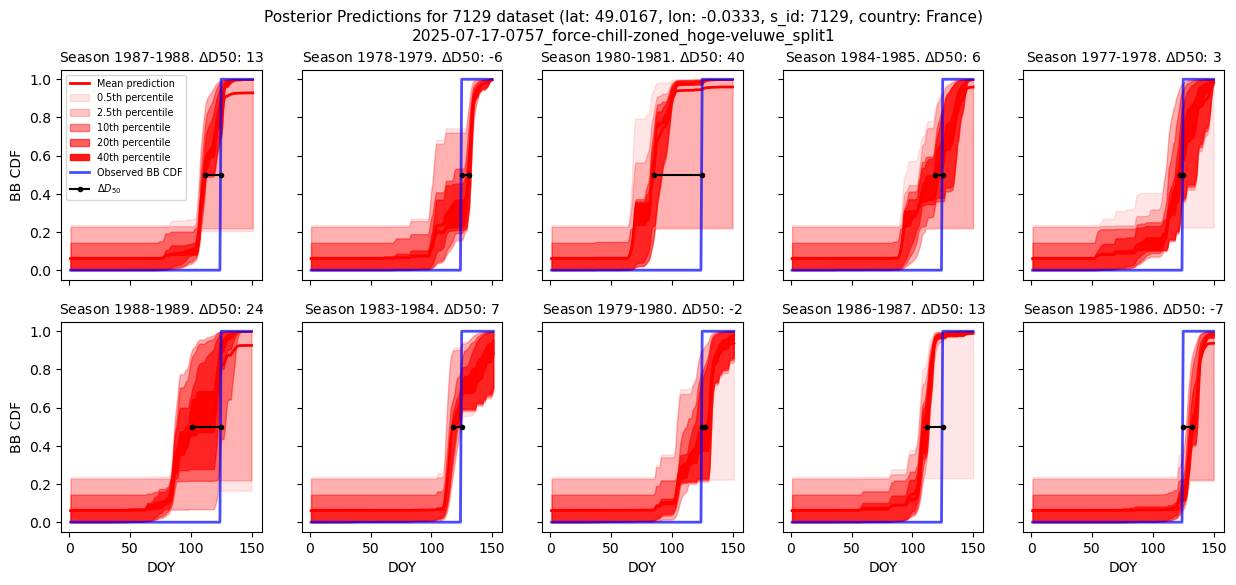

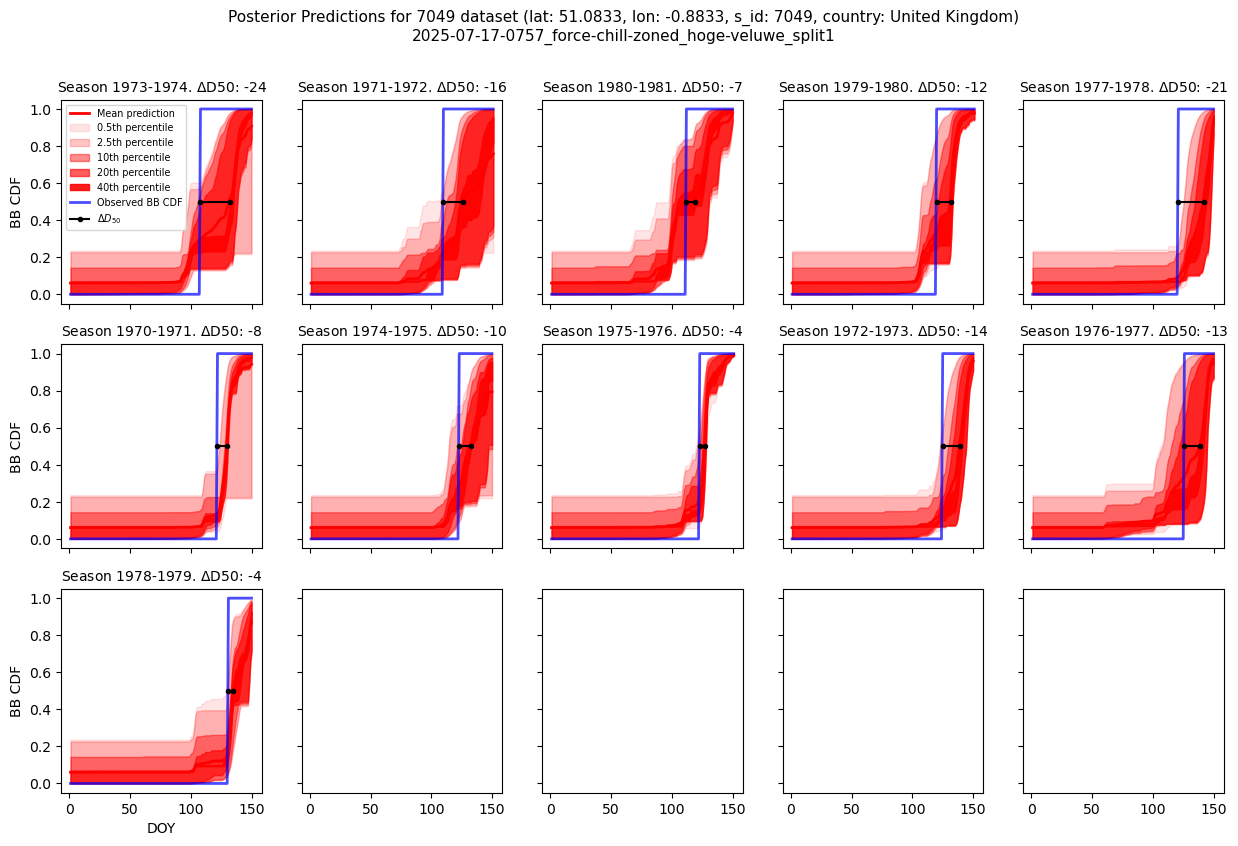

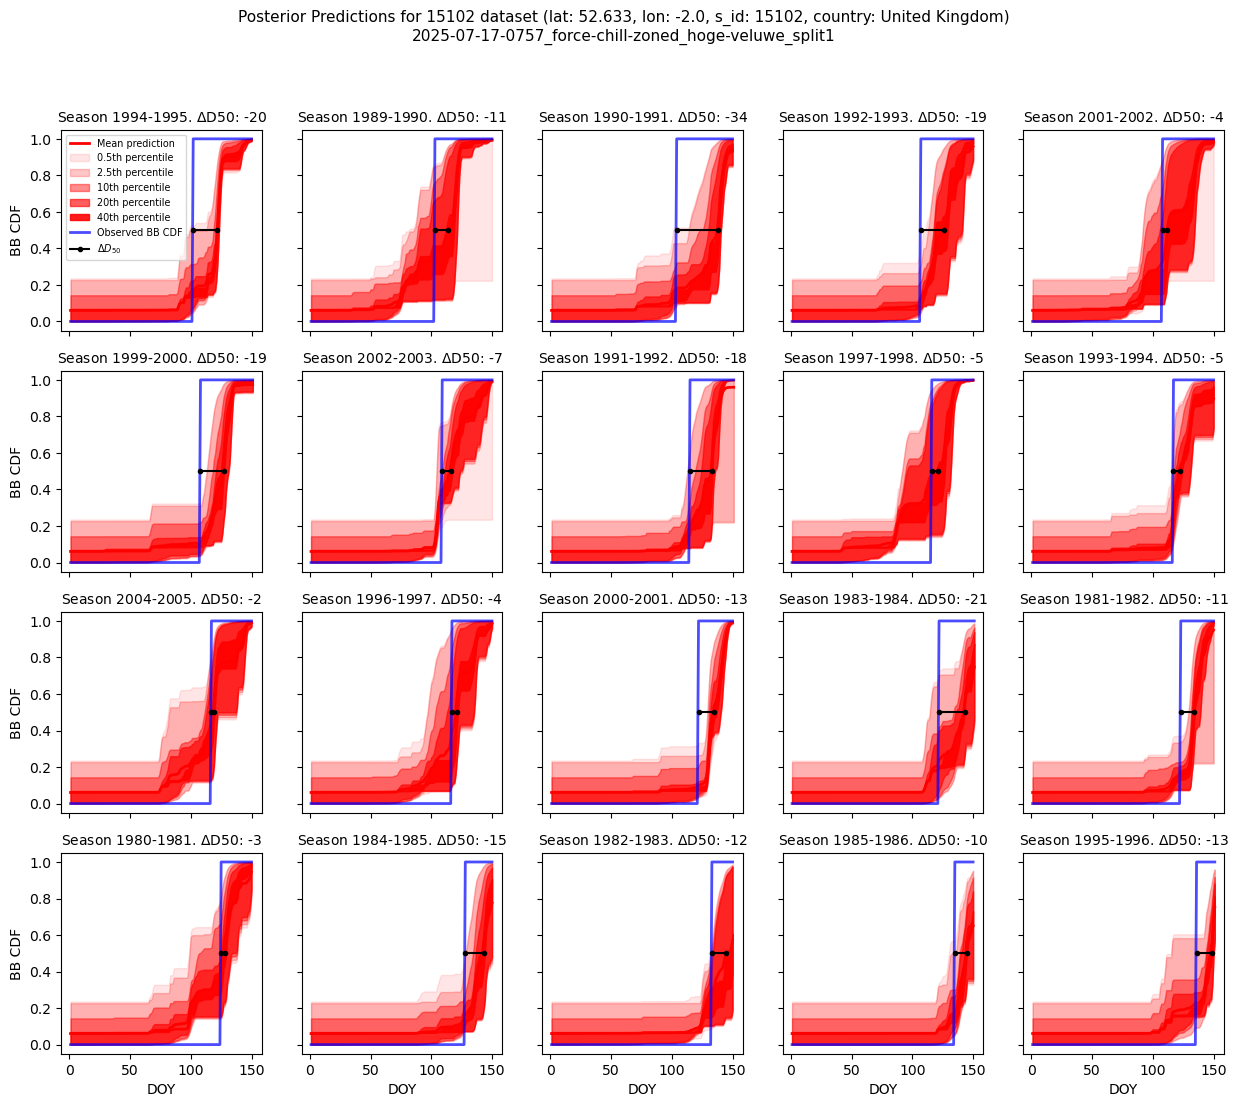

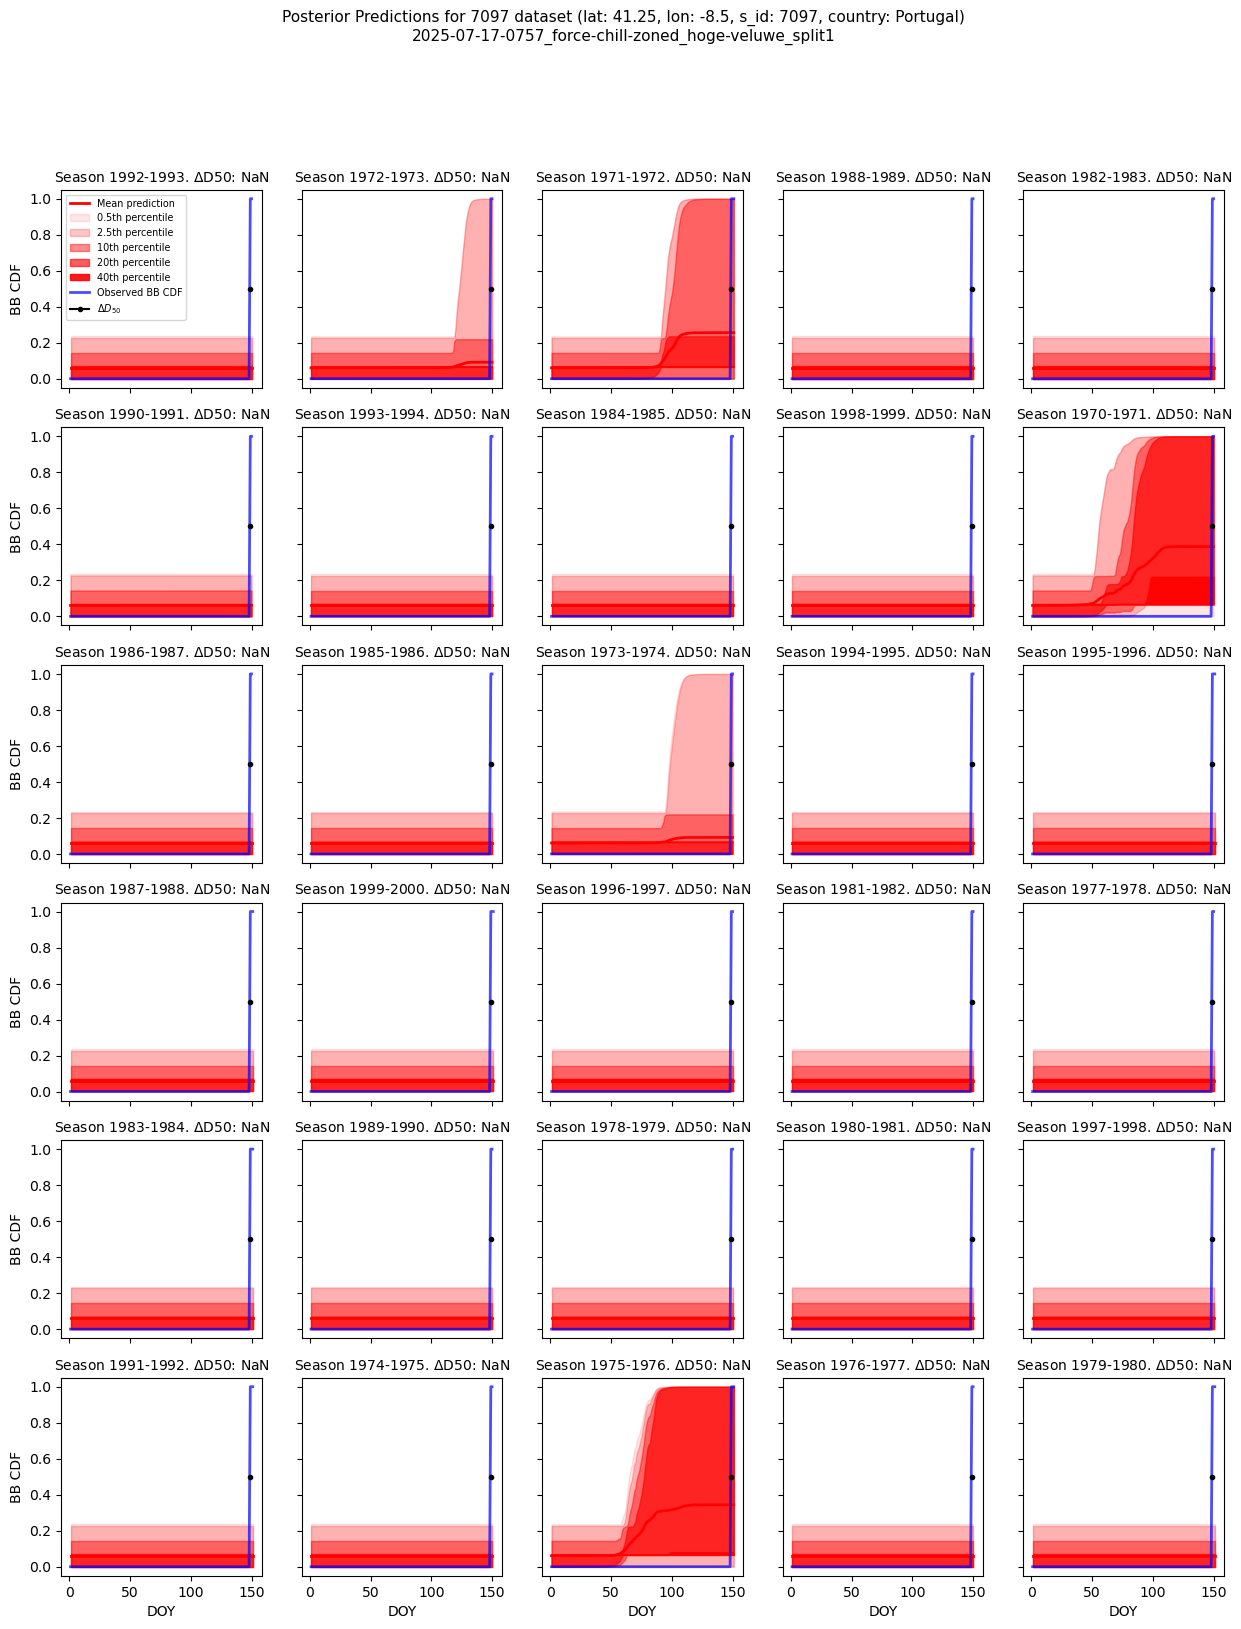

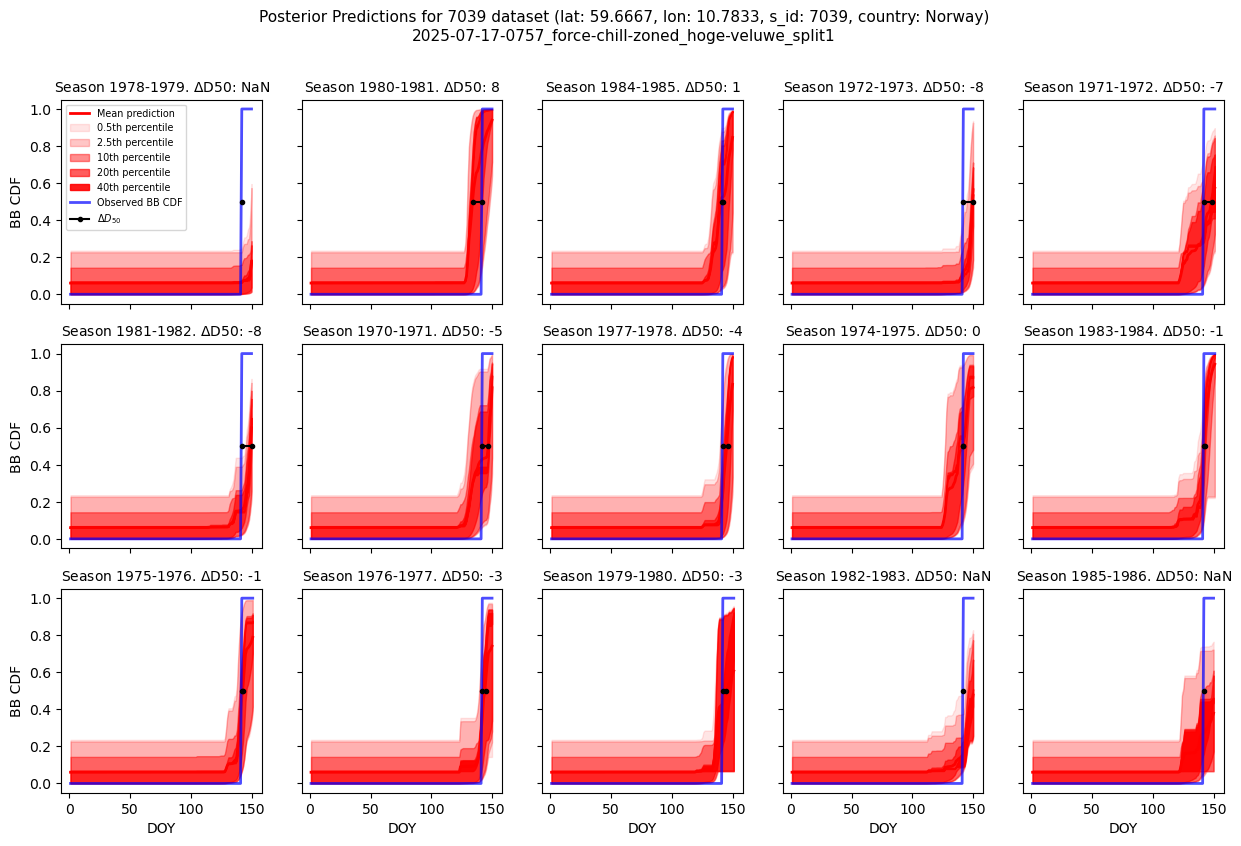

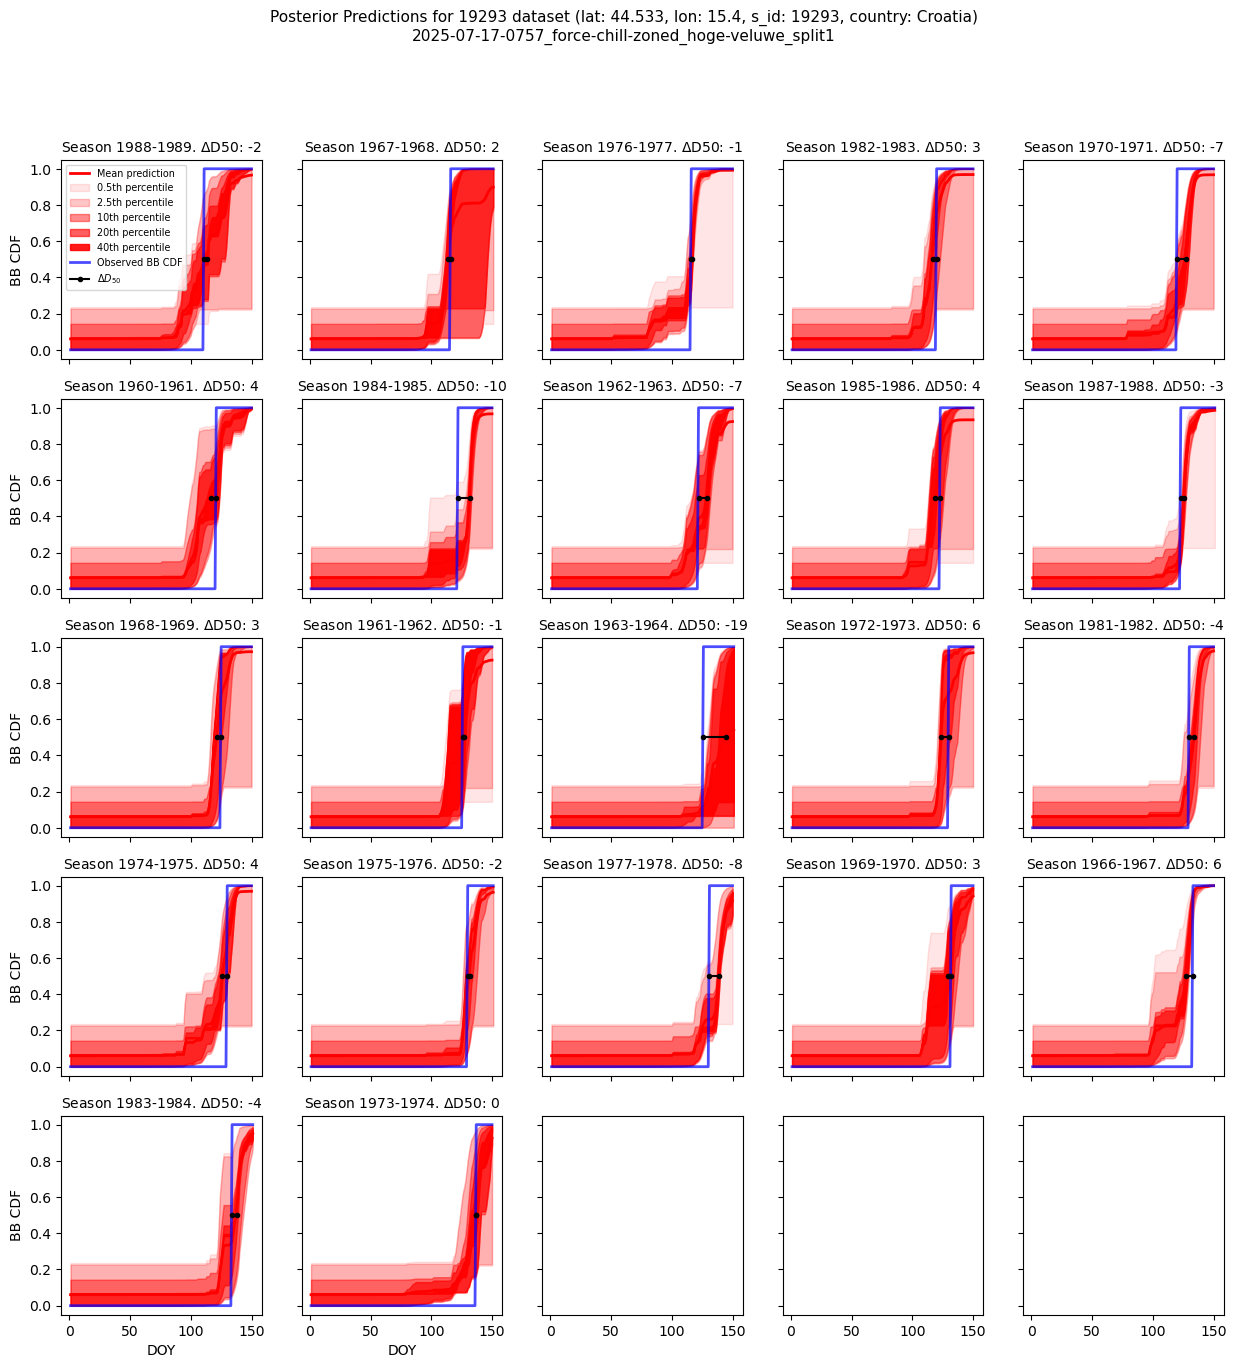

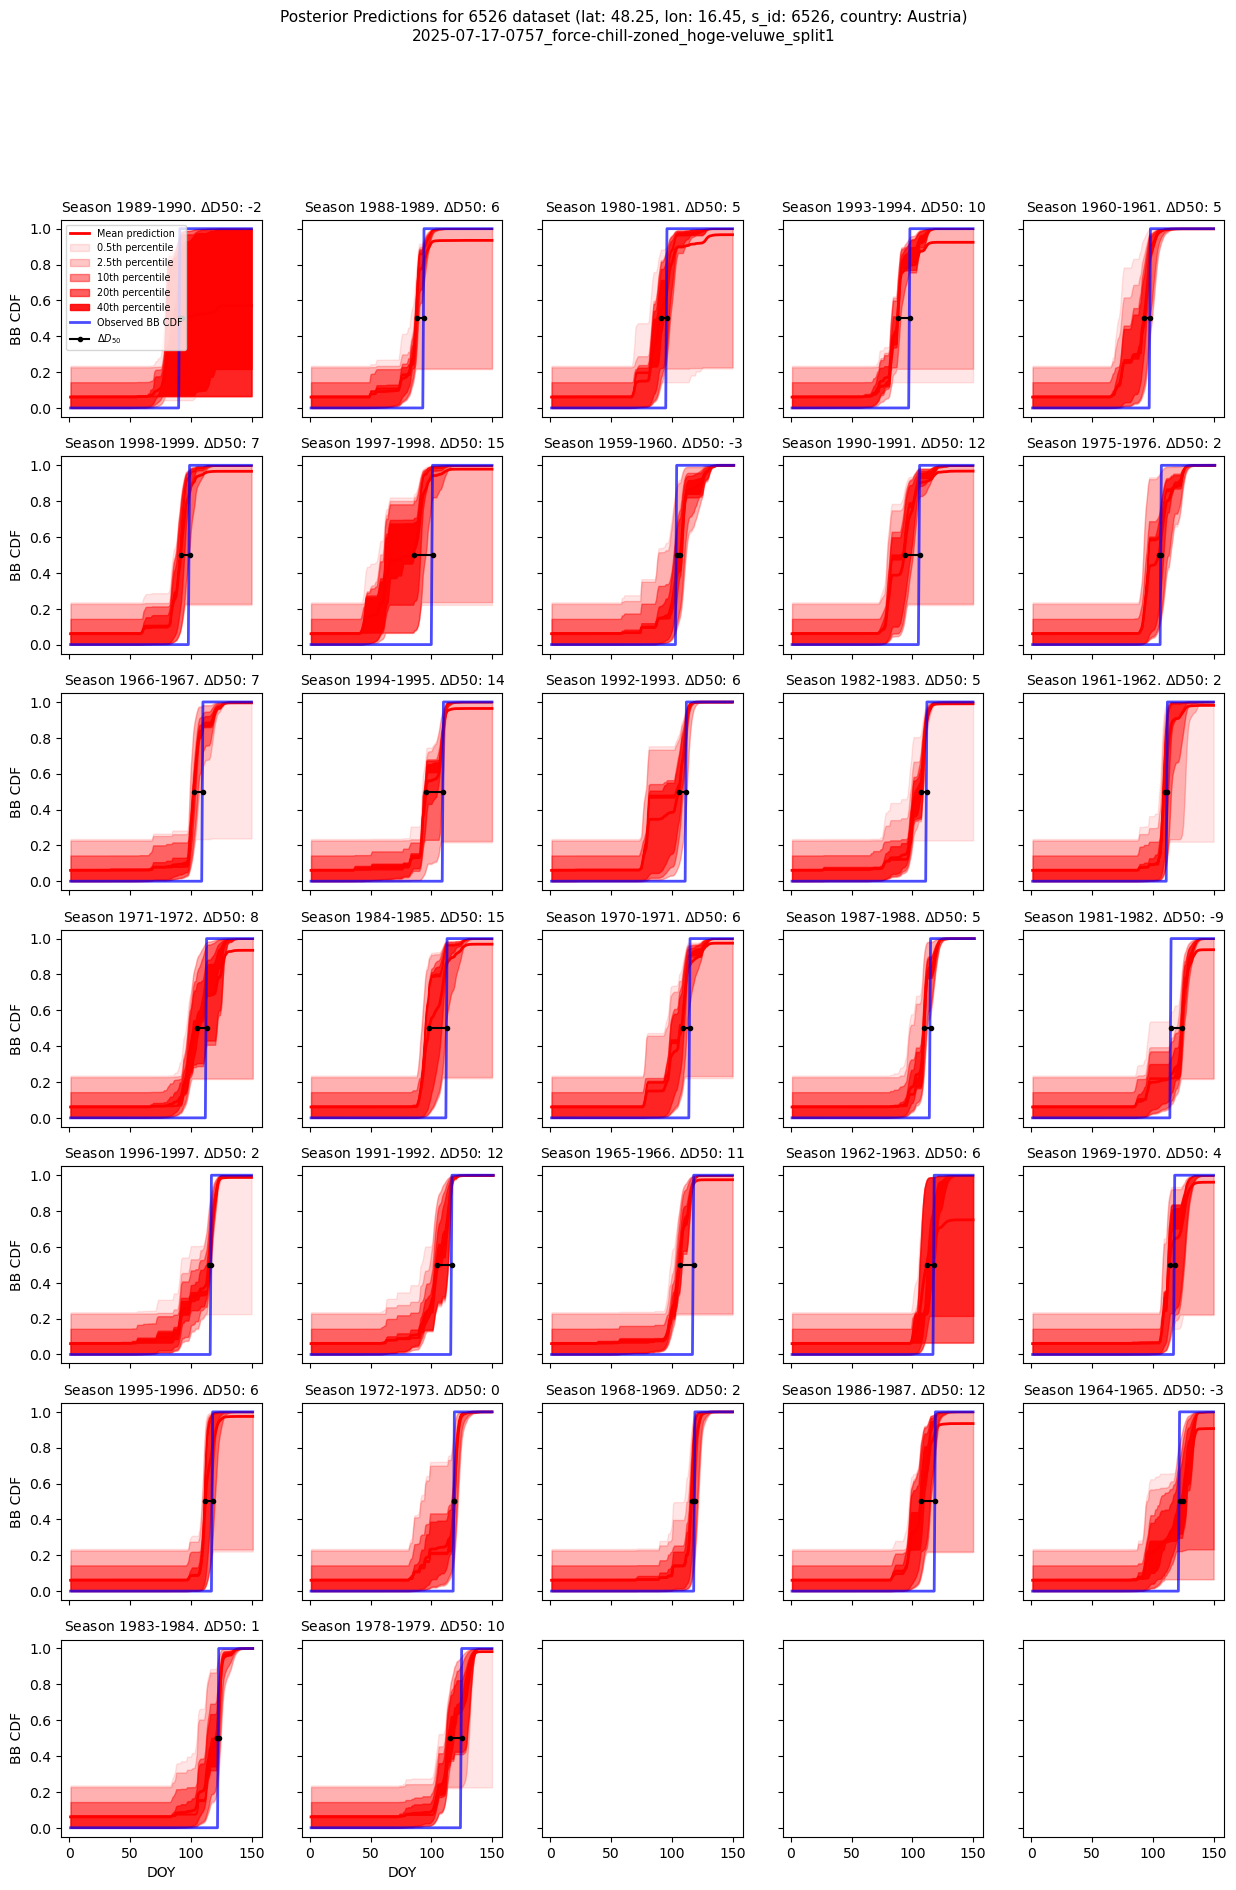

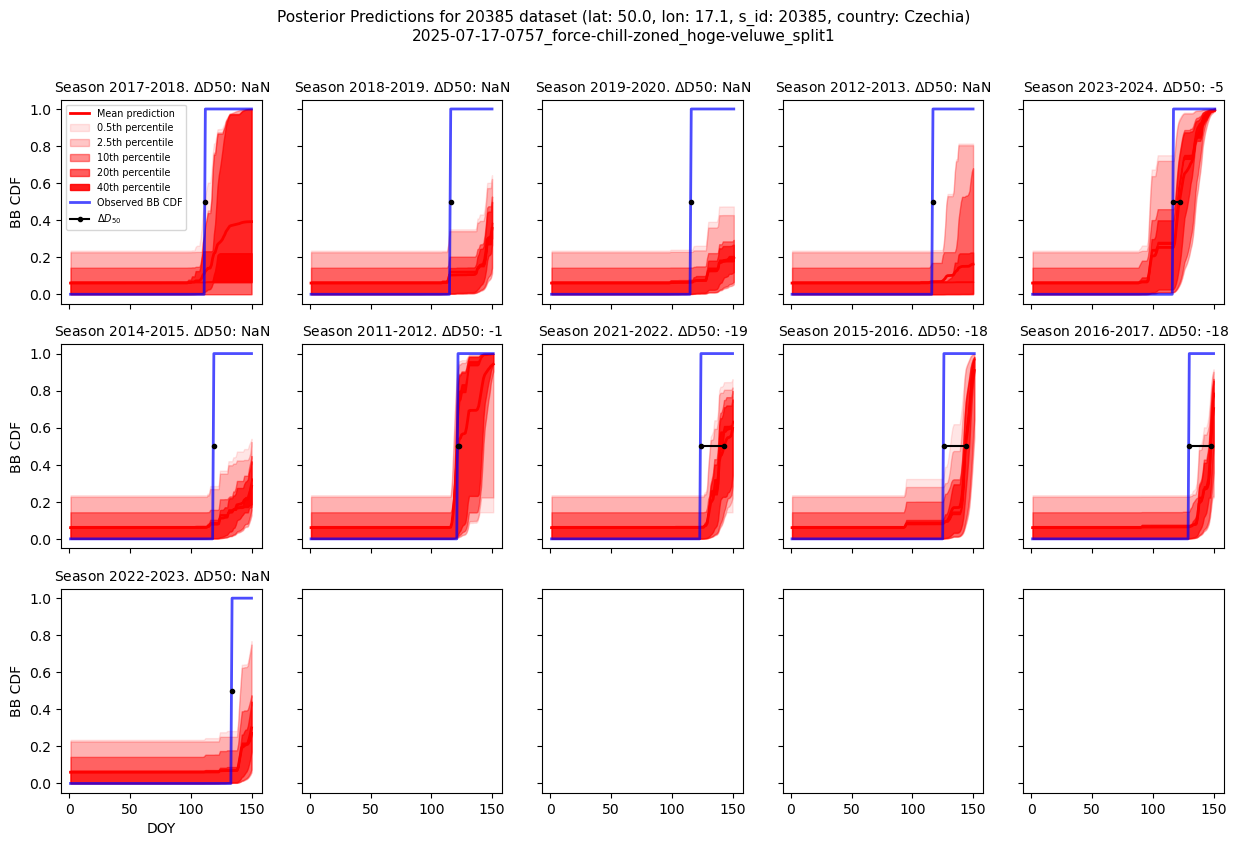

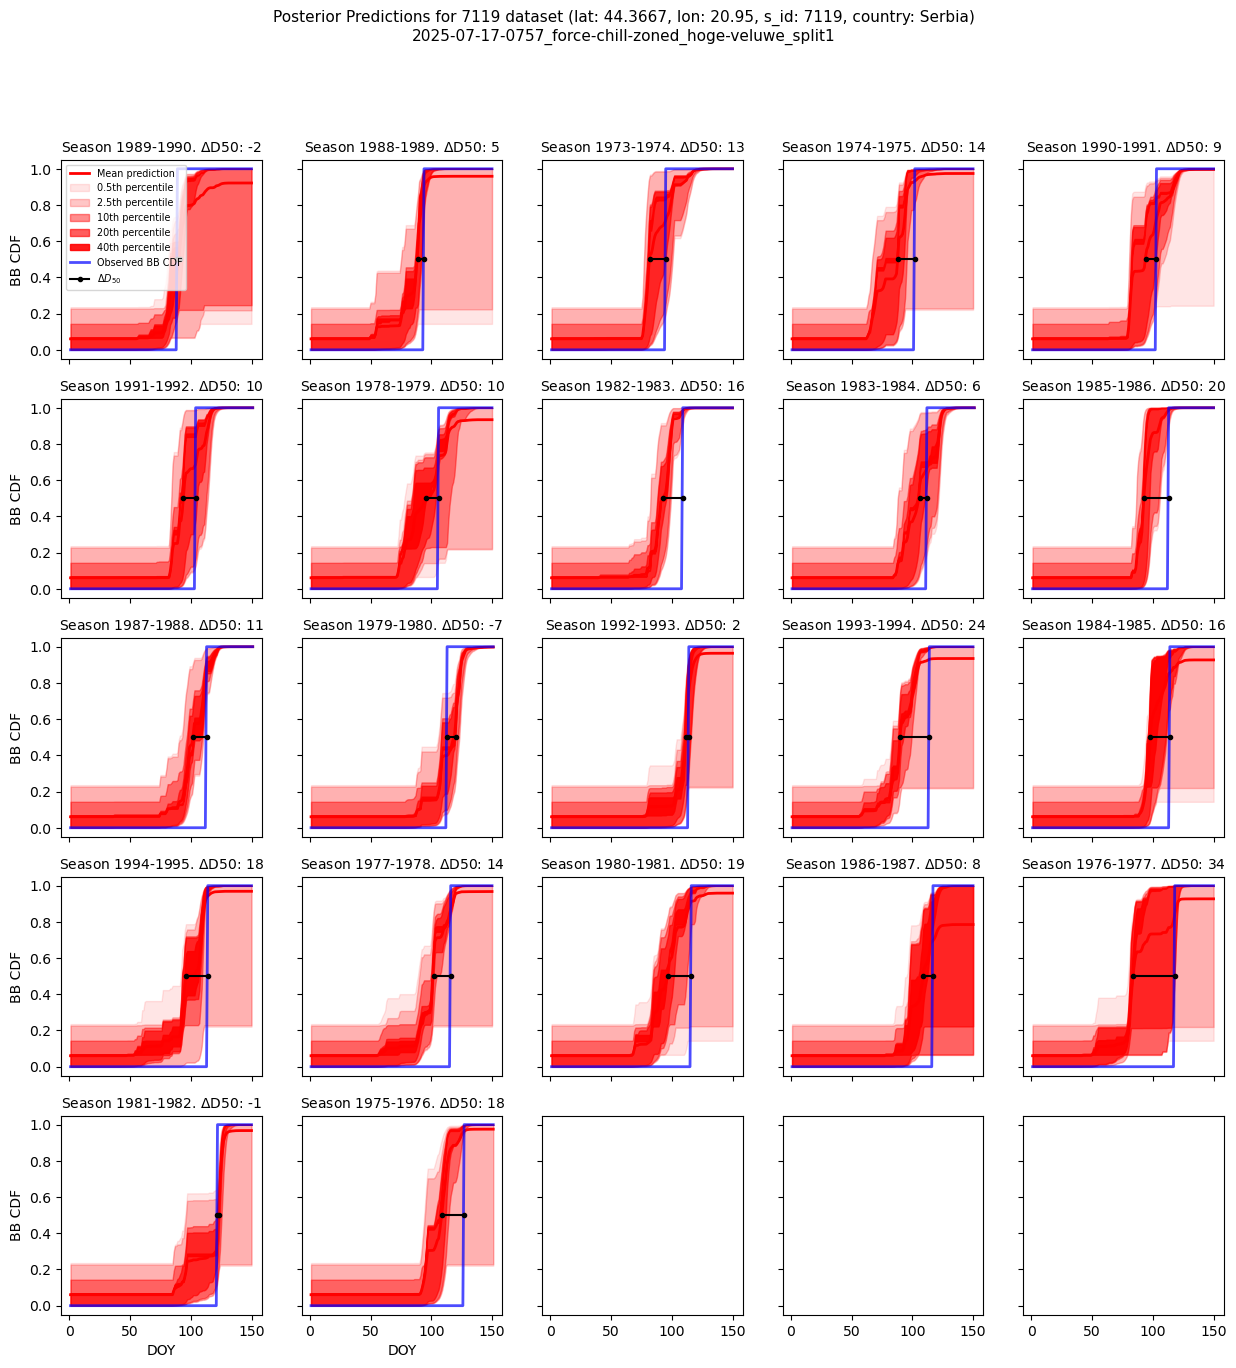

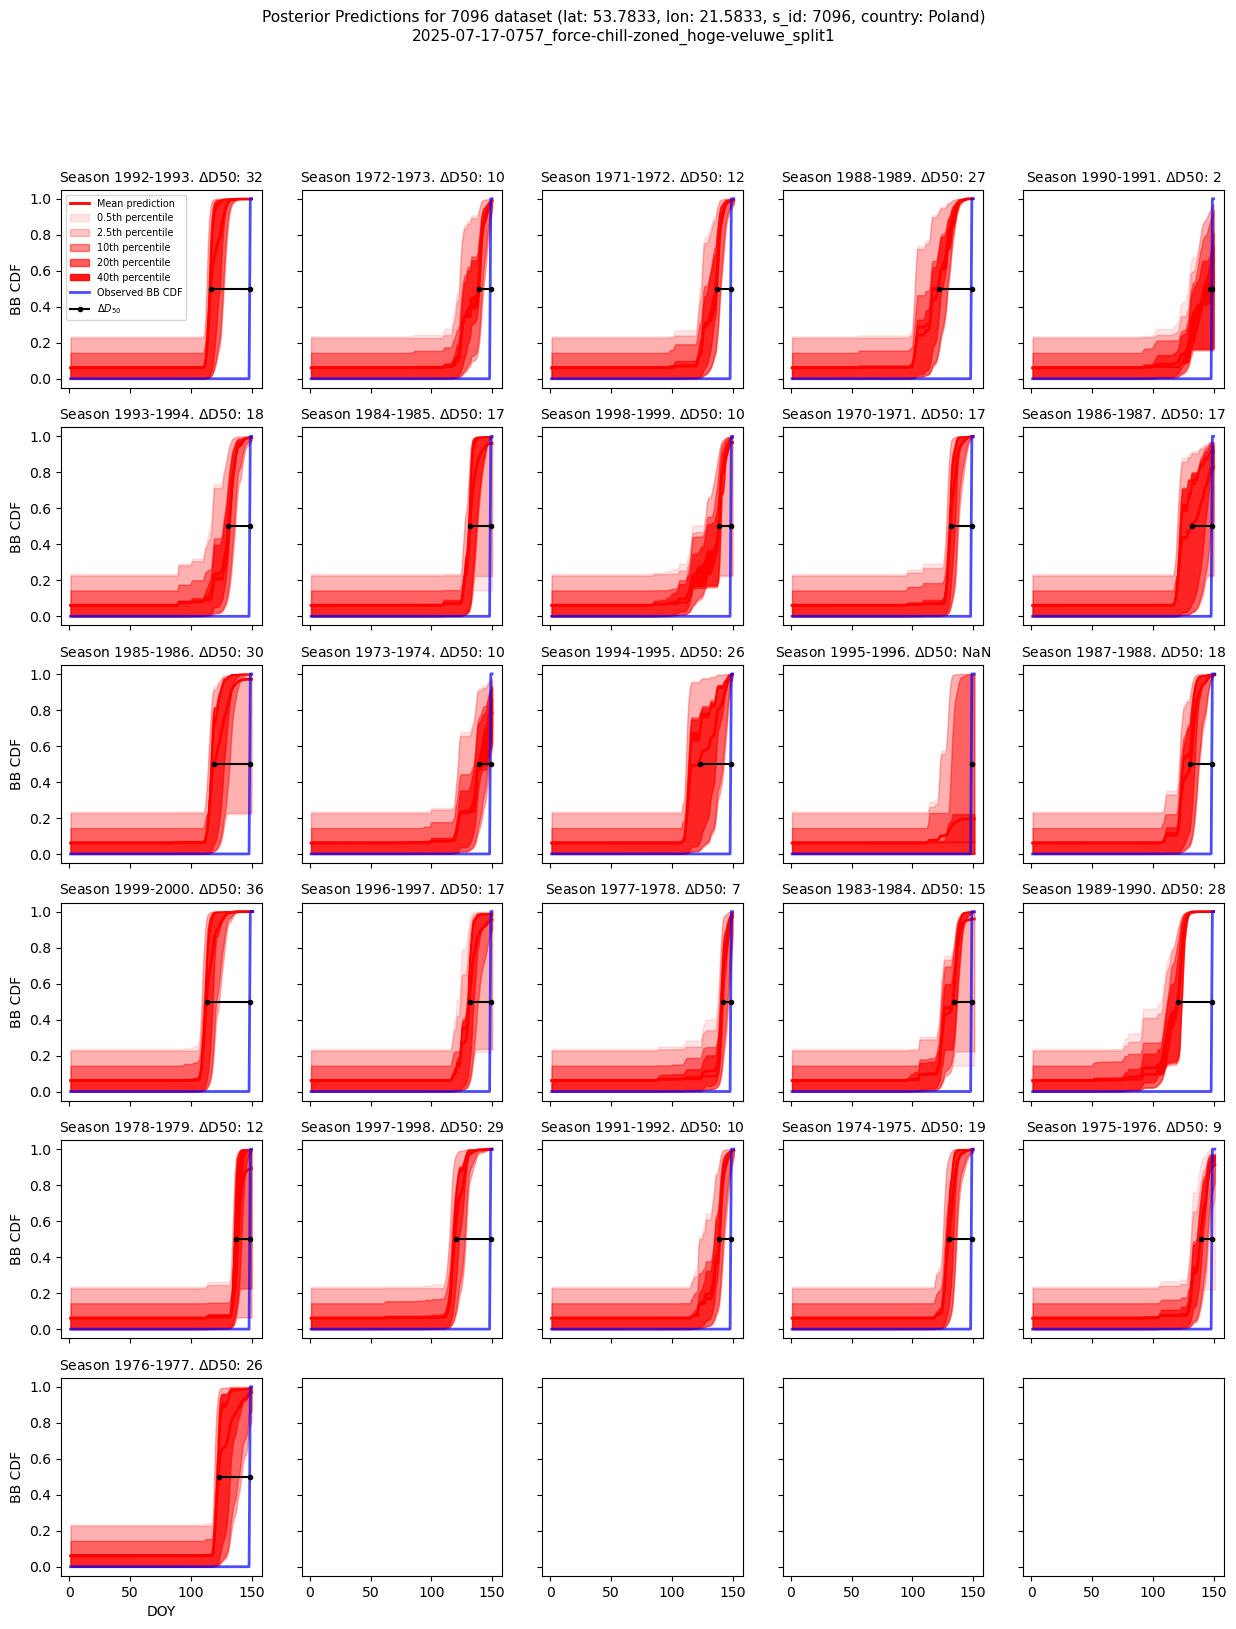

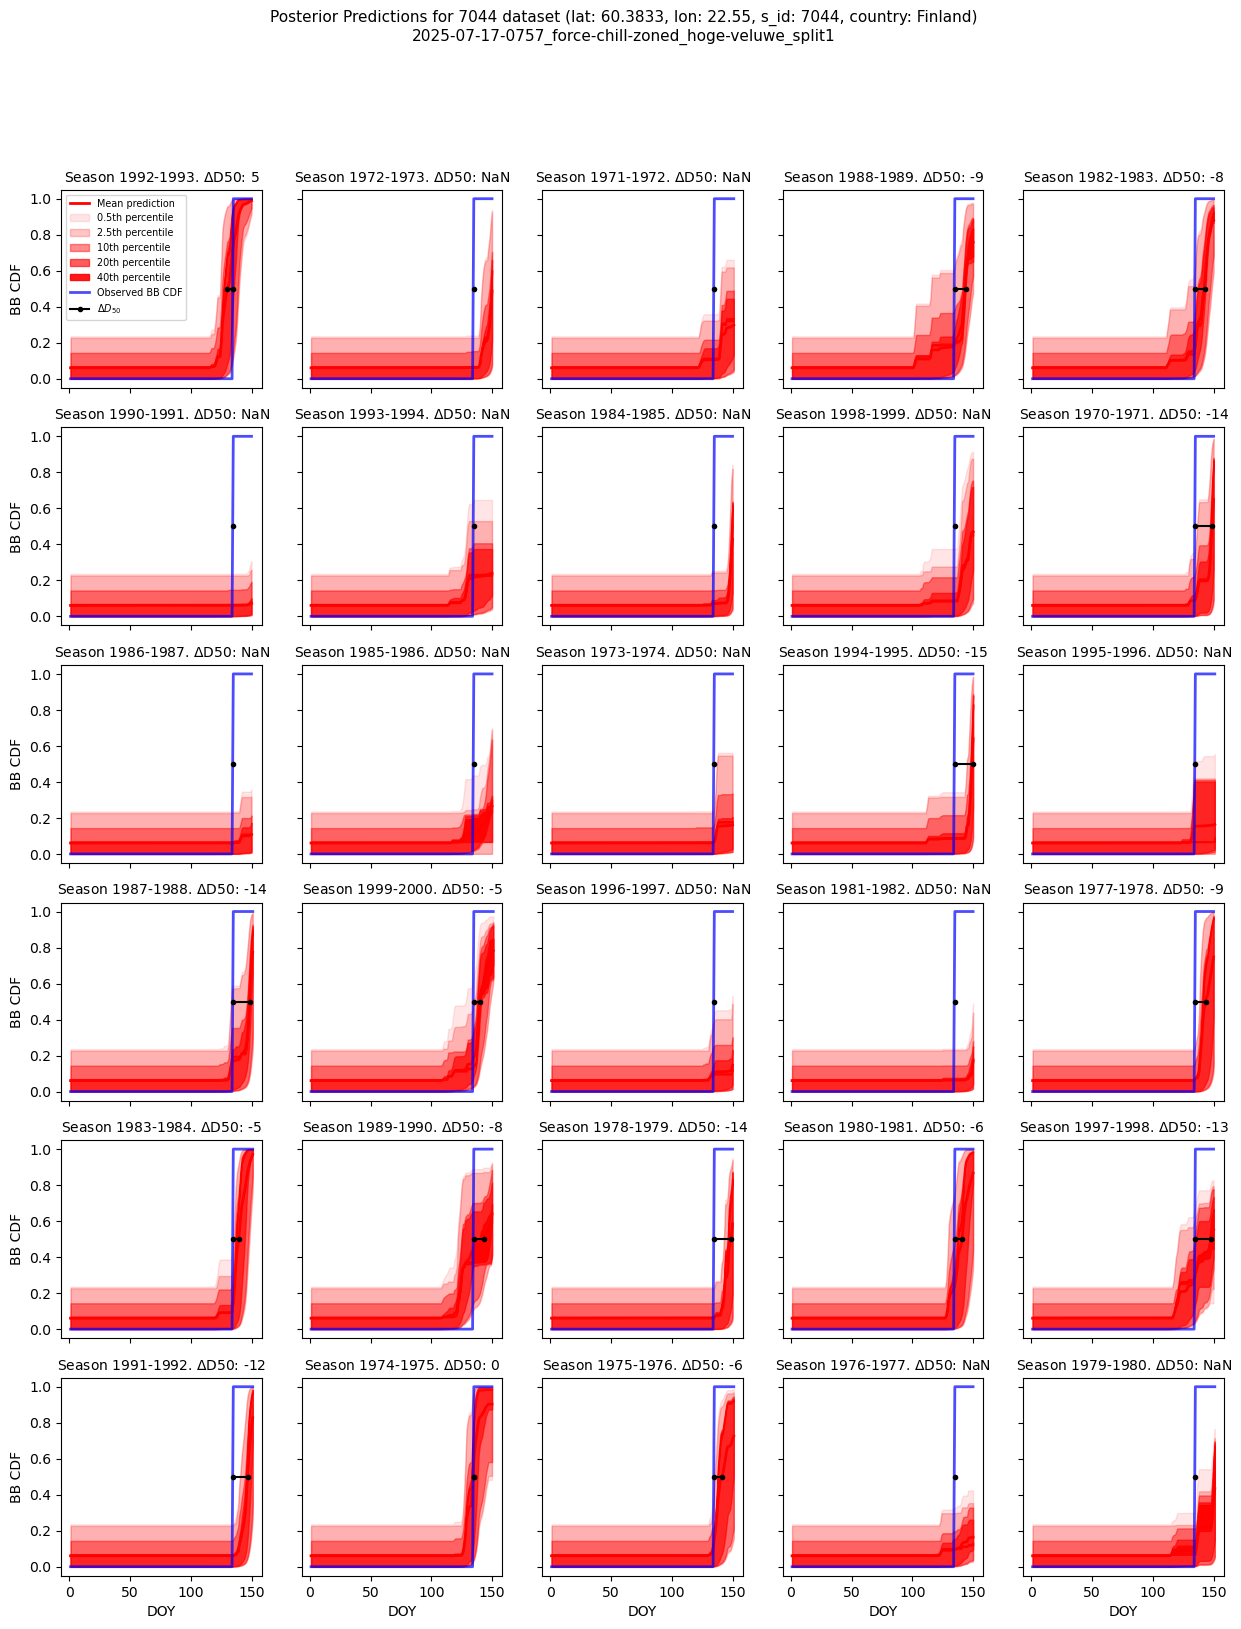

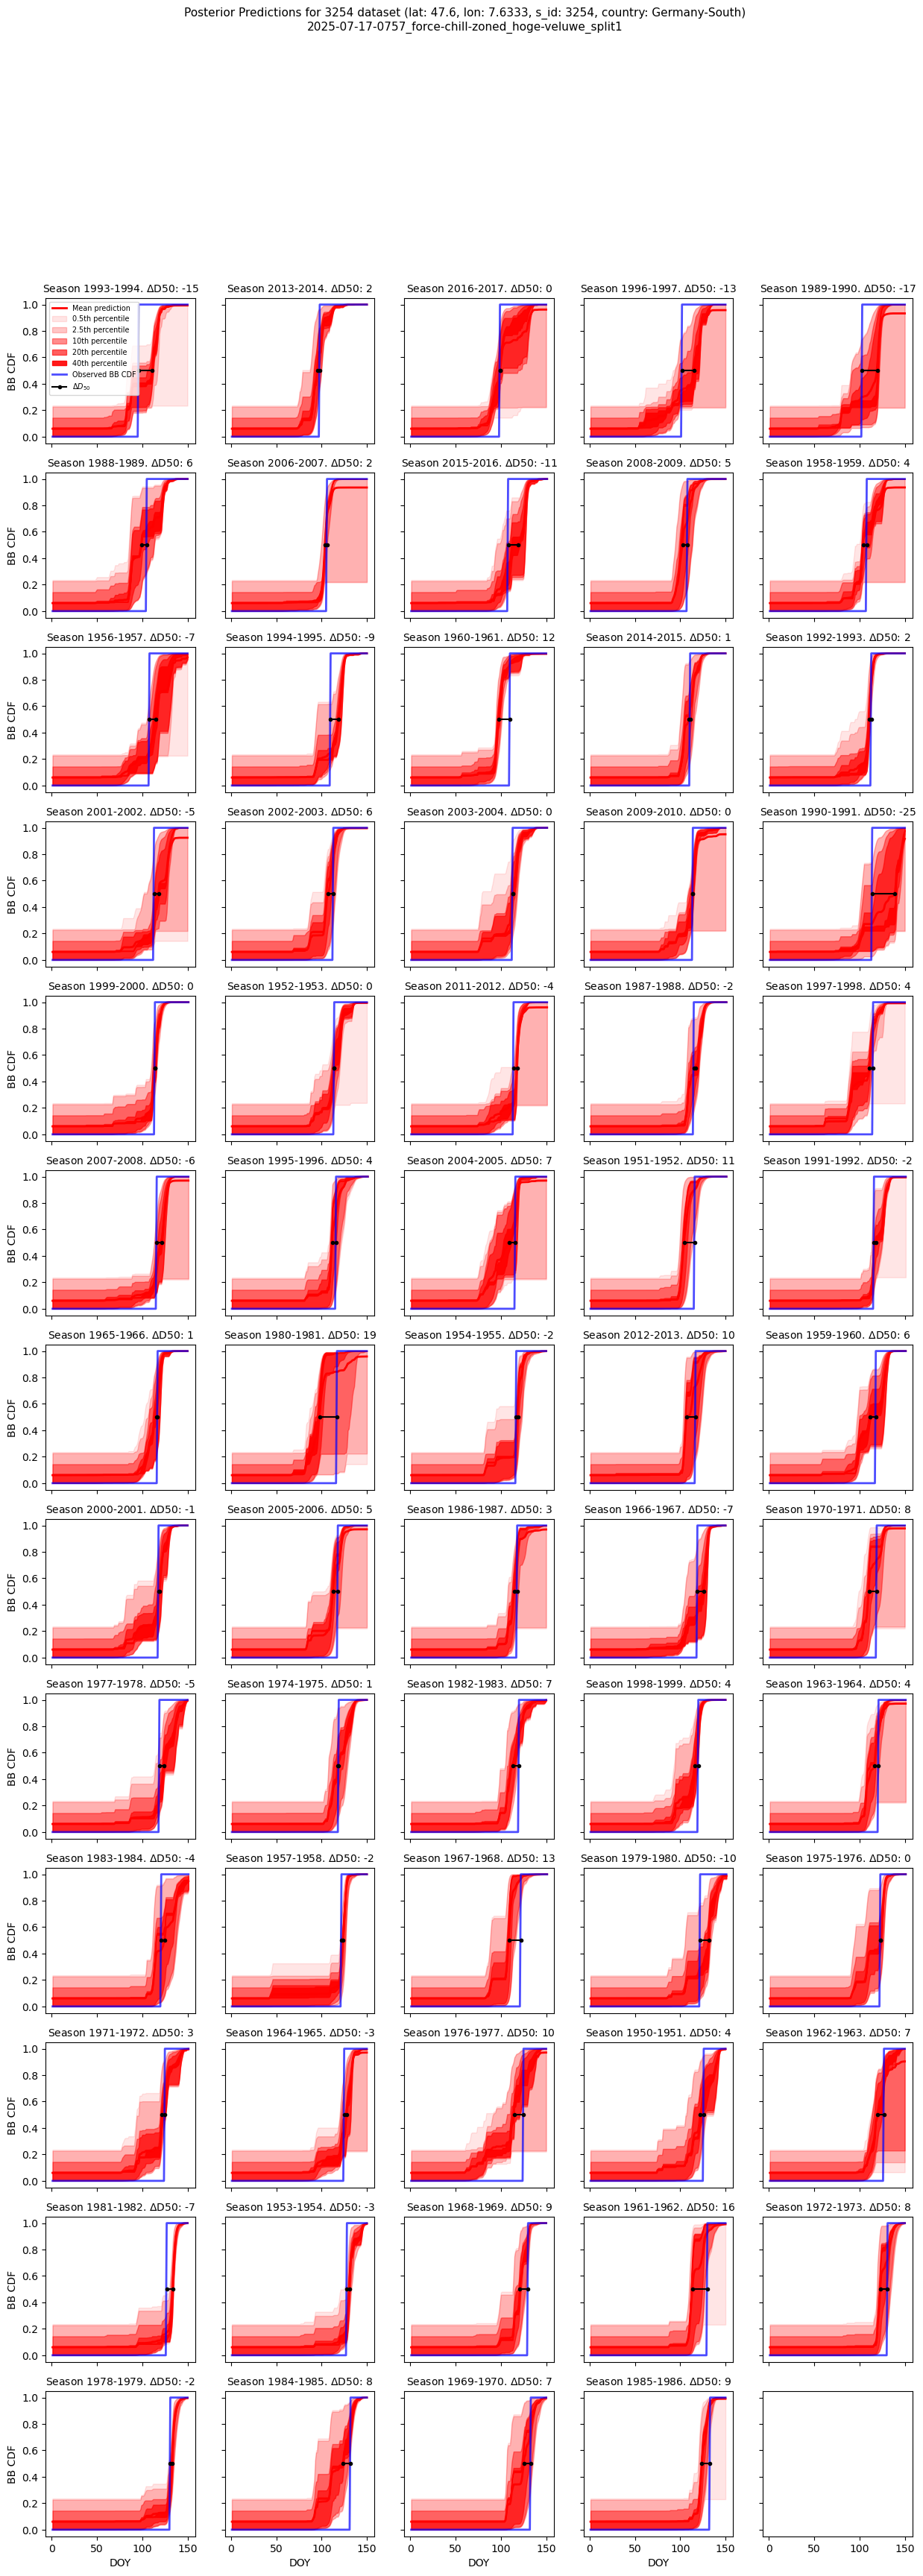

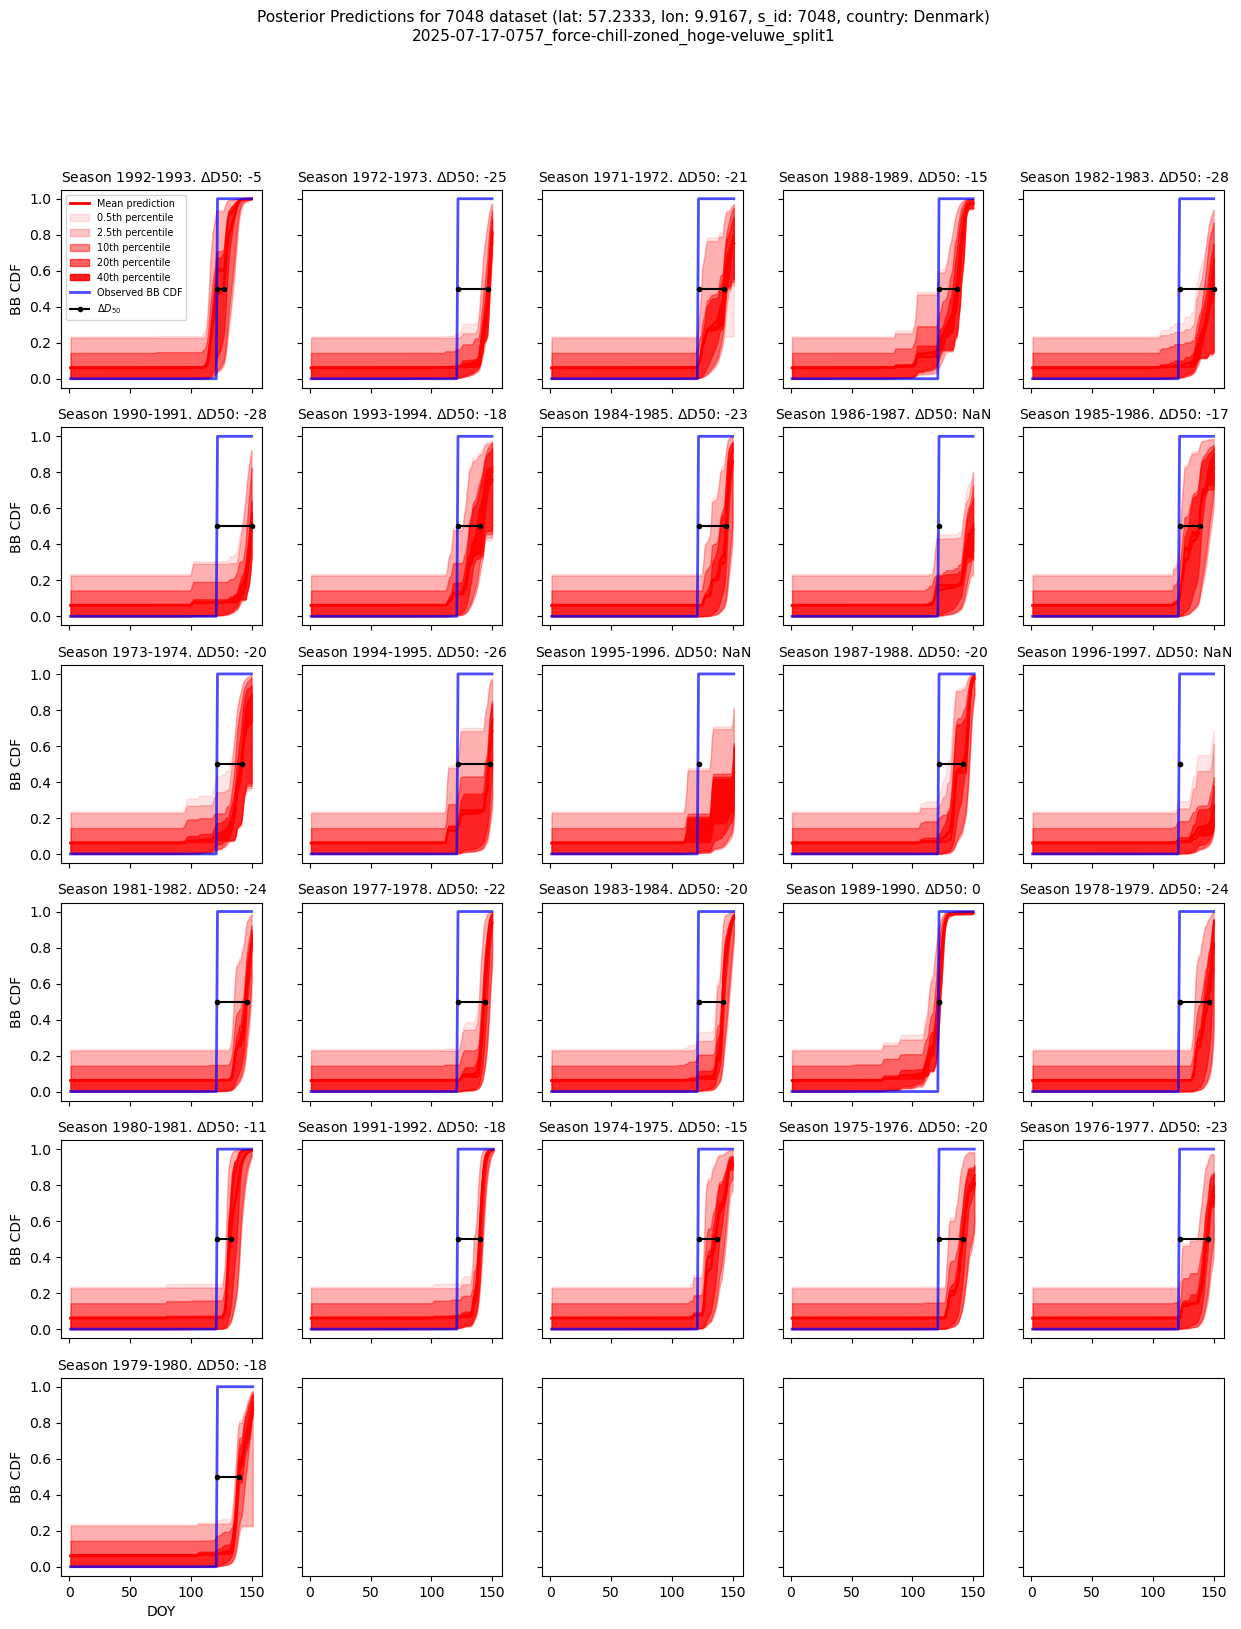

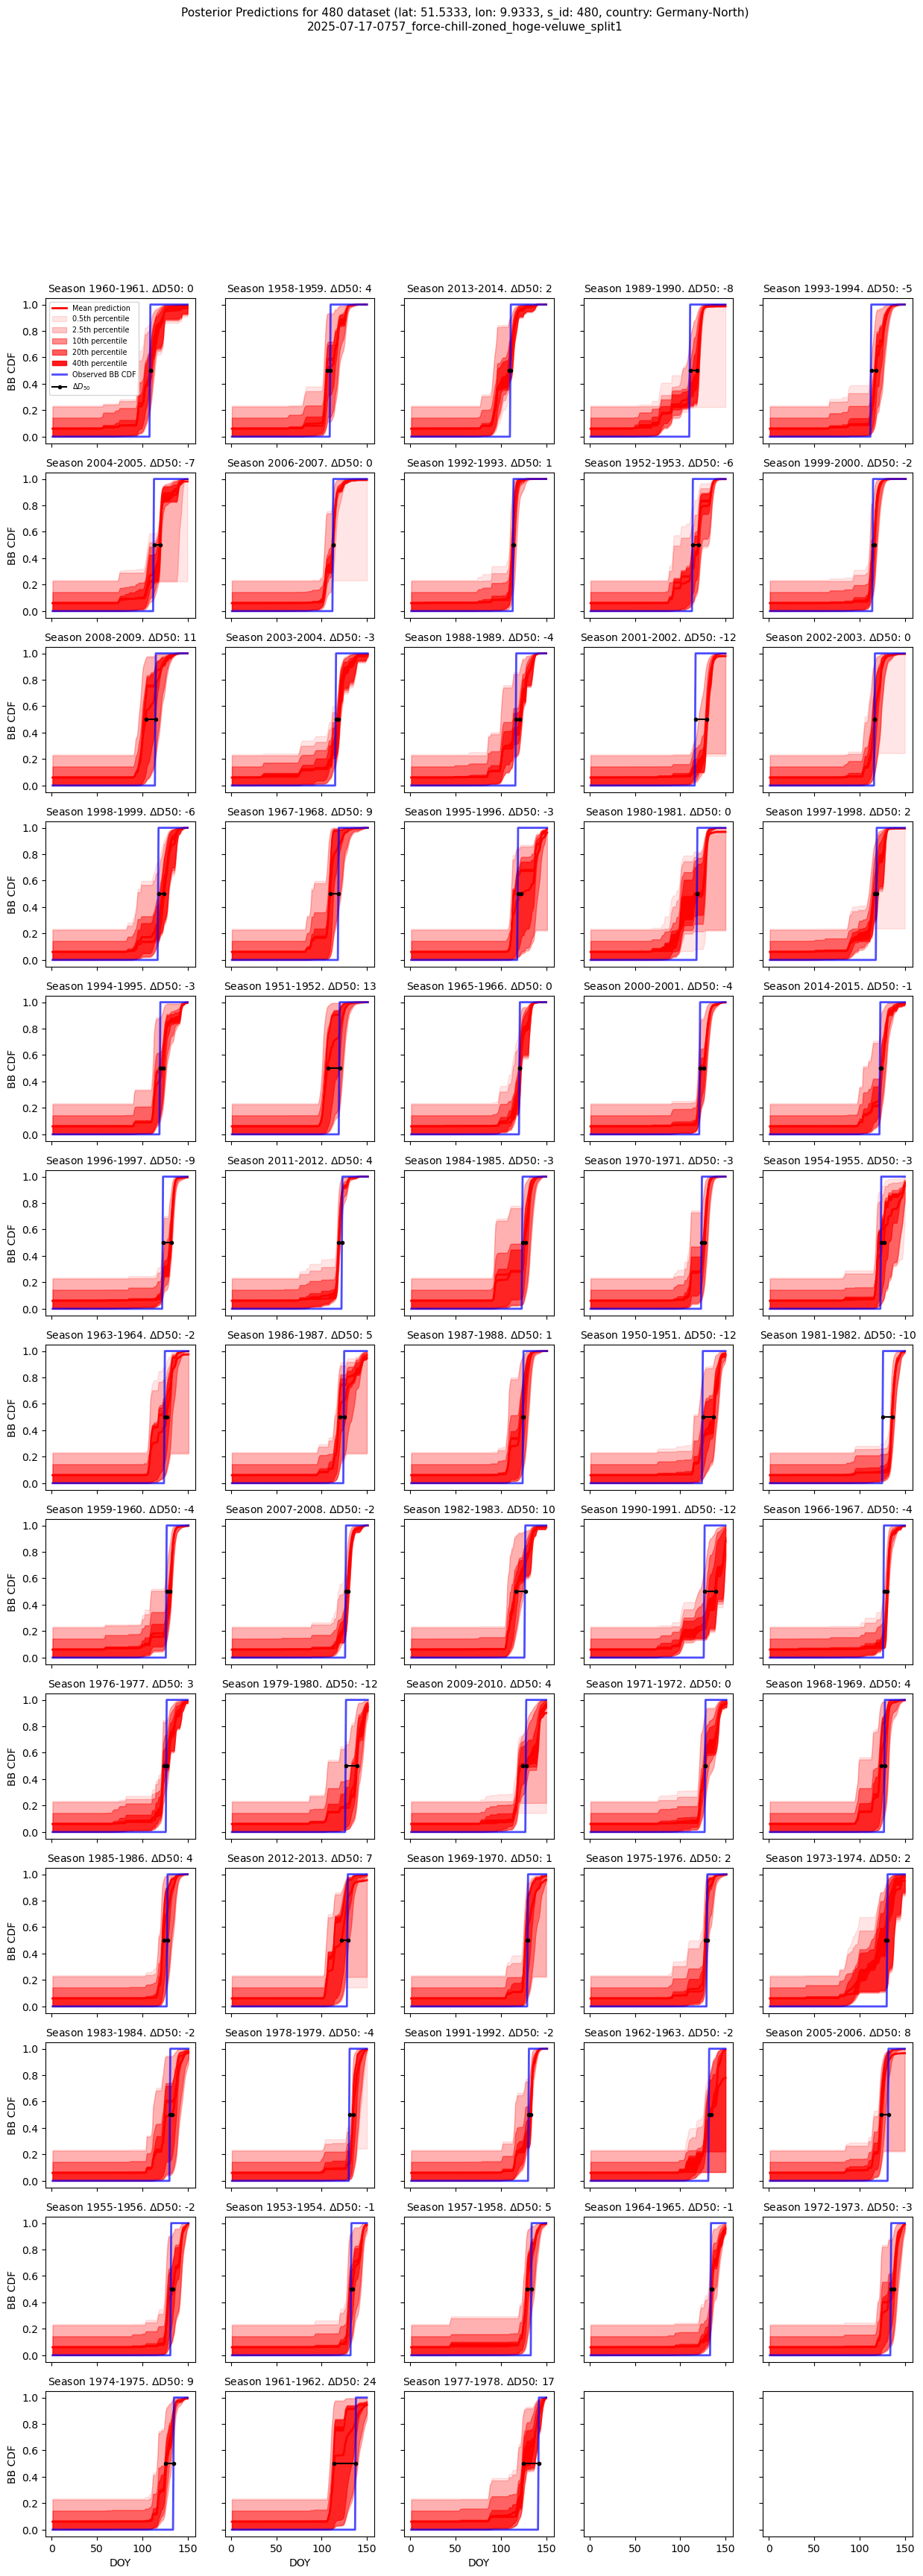

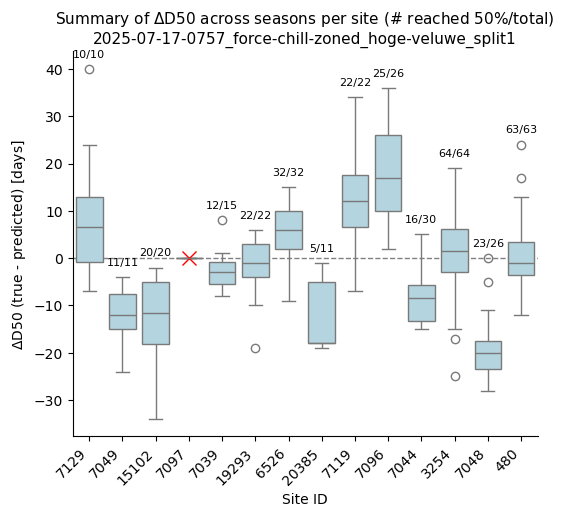

In [7]:
# dict_bb_cdf

def plot_posterior_predictions(dict_bb_cdf, coord_tuple=None, tt='test',
                               plot_order='season', save_fig=False,
                               fig_dir='/Users/tplas/repos/bayesian-budburst/fg/', 
                               fig_name_suffix=''):
    assert tt in dict_bb_cdf['mean'], f"Dataset '{tt}' not found in dict_bb_cdf"
    if save_fig:
        if not os.path.isdir(os.path.join(fig_dir, fig_name_suffix)):
            os.makedirs(os.path.join(fig_dir, fig_name_suffix), exist_ok=True)
    

    if plot_order == 'season':
        seasons = sorted(list(set(dict_bb_cdf['season'][tt])))
    elif plot_order == 'bb_midpoint':
        tmp_dict = {}
        for s in set(dict_bb_cdf['season'][tt]):
            idx_s = np.logical_and(np.array(dict_bb_cdf['season'][tt]) == s, np.array(dict_bb_cdf['doy'][tt] < 200))
            if np.sum(idx_s) == 0:
                continue
            bb_midpoint = np.where(dict_bb_cdf['bb_cdf'][tt][idx_s] > 0.5)[0][0]
            tmp_dict[s] = bb_midpoint  
        seasons = sorted(tmp_dict, key=tmp_dict.get)  
        
    else:
        raise ValueError(f"Invalid plot_order '{plot_order}'. Expected 'season' or 'bb_midpoint'.")
        
    dict_d50 = {}
    n_cols = 5
    n_rows = len(seasons) // n_cols + (len(seasons) % n_cols > 0)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), sharex=True, sharey=True)
    
    i_row, i_col = 0, 0
    for i_s, s in enumerate(seasons):
        ax = axes[i_row, i_col]
        idx_season = np.logical_and(np.array(dict_bb_cdf['season'][tt]) == s, np.array(dict_bb_cdf['doy'][tt] < 200))
        x_arr = dict_bb_cdf['doy'][tt][idx_season]
        
        ax.plot(x_arr, dict_bb_cdf['mean'][tt][idx_season], label='Mean prediction', color='red', alpha=1, linewidth=2)
        for perc in [0.5, 2.5, 10, 20, 40]:
            ax.fill_between(x=x_arr, y1=dict_bb_cdf[f'perc_{perc}'][tt][idx_season], y2=dict_bb_cdf[f'perc_{100 - perc}'][tt][idx_season],  
                            alpha=(perc / 50) ** 0.5, color='red', label=f'{perc}th percentile')
        ax.plot(x_arr, dict_bb_cdf['bb_cdf'][tt][idx_season], label='Observed BB CDF', color='blue', alpha=0.7, linewidth=2)

        d50_data = x_arr[np.where(dict_bb_cdf['bb_cdf'][tt][idx_season] >= 0.5)[0][0]]
        inds_pred_d50 = np.where(dict_bb_cdf['mean'][tt][idx_season] >= 0.5)[0]
        d50_pred = x_arr[inds_pred_d50[0]] if not len(inds_pred_d50) == 0 else np.nan
        delta_d50 = d50_data - d50_pred
        min_d50 = min(d50_data, d50_pred)
        dict_d50[s] = delta_d50
        ax.plot([min_d50, min_d50 + abs(delta_d50)], [0.5, 0.5], color='k', marker='o', 
                label=r"$\Delta D_{50}$", markersize=3)
        
        if i_col == 0:
            ax.set_ylabel('BB CDF')
        if i_row == n_rows - 1:
            ax.set_xlabel('DOY')
        ax.set_title(f'Season {s}. ' + r"$\Delta$" + f'D50: {int(delta_d50) if not np.isnan(delta_d50) else 'NaN'}', fontsize=10)

        if i_s == 0:
            ax.legend(loc='upper left', fontsize='x-small')

        i_col += 1
        if i_col == n_cols:
            i_col = 0
            i_row += 1

    if coord_tuple is not None:
        if type(coord_tuple) == dict:
            coord_tuple = coord_tuple[tt]
        coord_str = ', '.join([f"{k}: {getattr(coord_tuple, k)}"for k in coord_tuple._fields])
        fig.suptitle(f"Posterior Predictions for {tt} dataset ({coord_str})\n{fig_name_suffix}\n", fontsize=11)

    if save_fig:
        fig_path = os.path.join(fig_dir, f"{fig_name_suffix}", f"posterior_predictions_{tt}_{fig_name_suffix}.png")
        assert not os.path.isfile(fig_path), f"Figure already exists at {fig_path}. Please choose a different fig_name_suffix or set save_fig=False to avoid overwriting."
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        # print(f"Figure saved to {fig_path}")

    return dict_d50

mode_model = pu.get_name(infer_chilling=INFER_CHILLING, zoned_chilling=ZONED_CHILLING, photoperiod=PHOTOPERIOD)
fig_suffix = f"{datetime_str_posterior}_{mode_model}_{location_str}_split{split_n}"
dict_d50_all = {}
save_fig = True
print(fig_suffix)
for tt in dict_bb_cdf['mean'].keys():
    dict_d50_all[tt] = plot_posterior_predictions(dict_bb_cdf, coord_tuple=coord_dict, tt=tt, plot_order='bb_midpoint',
                               save_fig=save_fig, fig_name_suffix=fig_suffix)


fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
for ii, (k, v) in enumerate(dict_d50_all.items()):
    vals = [x for x in v.values()]
    mean_val = np.nanmean(vals)
    n_non_nan = np.sum(~np.isnan(vals))
    n_total = len(vals)
    if n_non_nan == 0:
        sns.boxplot(x=[ii], y=0, ax=ax, color='lightblue')
        ax.plot(ii, 0, marker='x', color='red', markersize=10)
    ## barplot
    # ax.bar(ii, mean_val, yerr=np.std(vals), capsize=5, facecolor='lightblue', edgecolor='black')
    # ax.text(ii, max(0, mean_val + np.std(vals) + 0.5), f'{n_non_nan}/{n_total}', 
    #         ha='center', va='bottom', fontsize=8)

    ## boxplot
    else:
        sns.boxplot(x=[ii]*len(vals), y=vals, ax=ax, color='lightblue')
    ax.text(ii, np.nanmax(vals) + 2, f'{n_non_nan}/{n_total}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(range(len(dict_d50_all.keys())))
ax.set_xticklabels([k for k in dict_d50_all.keys()], rotation=45, ha='right');
ax.set_ylabel(r'$\Delta$' + 'D50 (true - predicted) [days]')
ax.set_xlabel('Site ID')
ax.set_title(f"Summary of " + r'$\Delta$' + f"D50 across seasons per site (# reached 50%/total) \n{fig_suffix}", fontsize=11)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)

if save_fig:
    fig_path = os.path.join('/Users/tplas/repos/bayesian-budburst/fg/', f"{fig_suffix}", f"delta_d50_summary_{fig_suffix}.png")
    assert not os.path.isfile(fig_path), f"Figure already exists at {fig_path}. Please choose a different fig_name_suffix or set save_fig=False to avoid overwriting."
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    # print(f"Figure saved to {fig_path}")

In [125]:
np.where(dict_bb_cdf['mean'][tt][1813:1888] >= 0.5)[0]

array([], dtype=int64)

In [ ]:
# ##### MOTHS
# posterior_samples, dict_df = load_posterior_and_data(
#     datetime_str_posterior='2025-09-18-0937',
#     location_str='hv',
#     split_n=2,  # split to LOAD model from and to CREATE new data from
#     n_splits=3,  # number of splits to CREATE new data from
#     split_method='sequential',
#     get_train=False,  # return train data or not
#     fp='/Users/tplas/data/2025-09 bayesian moth runs/2025-09-18-0937_force_winter-moth_hv/posterior_samples_2025-09-18-0937_split-0.nc',
#     infer_chilling=INFER_CHILLING,
#     zoned_chilling=ZONED_CHILLING,
#     moth_datatype=True,
#     location_list_obs=['hv']
# )

In [13]:
## Load temperature scenarios to replace temperature in test data

def get_tempererature_scenario(scenario='RCP85', average_temp_scenarios=True, member_id=None, ind_member=0):
    SCENARIO = scenario
    if not average_temp_scenarios:
        '''either use member_id directly, or use ind_member to select from sorted unique member_ids'''
        assert member_id is not None or ind_member is not None, "Either member_id or ind_member must be provided if not averaging temperature scenarios."
    else:
        print('Averaging temperature scenarios.')

    df_temp_scen = pd.read_csv('../../data/scenario_temperatures.csv')
    print(df_temp_scen.scenario_name.unique())

    df_temp_scen = df_temp_scen[df_temp_scen.scenario_name == SCENARIO]
    print(f'There are {len(df_temp_scen)} rows, {df_temp_scen["time"].nunique()} unique dates.')

    if average_temp_scenarios:
        df_temp_scen['TREFHT_mean'] = df_temp_scen.groupby(['time'])['TREFHT'].transform('mean')
        df_temp_scen.drop(columns=['member_id', 'TREFHT'], inplace=True)
        df_temp_scen.drop_duplicates(inplace=True)
        print(f'After groupby and mean and dropping duplicates, there are {len(df_temp_scen)} rows.')
        df_temp_scen['temperature'] = df_temp_scen['TREFHT_mean'] - 273.15  # Convert from Kelvin to Celsius
        df_temp_scen.drop(columns=['TREFHT_mean'], inplace=True)
    else:
        assert SCENARIO == 'RCP85', "Only RCP85 implemented currently (check consistency of value_coutns and int dtypes of member_id for other scenarios first)"
        df_temp_scen['member_id'] = df_temp_scen['member_id'].astype(int)
        if member_id is not None:
            assert member_id in df_temp_scen['member_id'].values, f"member_id {member_id} not found in available member_ids."
            df_temp_scen = df_temp_scen[df_temp_scen['member_id'] == member_id]
            print(f'Using member_id = {member_id}, there are {len(df_temp_scen)} rows.')
        else:
            unique_member_ids = sorted(df_temp_scen['member_id'].unique())
            assert ind_member < len(unique_member_ids), f"ind_member {ind_member} out of range for available member_ids."
            selected_member_id = unique_member_ids[ind_member]
            df_temp_scen = df_temp_scen[df_temp_scen['member_id'] == selected_member_id]
            print(f'Using ind_member = {ind_member} (out of {len(unique_member_ids)}) which corresponds to member_id = {selected_member_id}, there are {len(df_temp_scen)} rows.')
        df_temp_scen['temperature'] = df_temp_scen['TREFHT'] - 273.15  # Convert from Kelvin to Celsius
        df_temp_scen.drop(columns=['TREFHT'], inplace=True)
        
    print(len(df_temp_scen), df_temp_scen.time.nunique(), 95 * 365)
    df_temp_scen['date'] = pd.to_datetime(df_temp_scen['time'], format='%Y-%m-%d')
    df_temp_scen['year'] = df_temp_scen['date'].dt.year
    df_temp_scen['doy'] = df_temp_scen['date'].dt.dayofyear

    return df_temp_scen

def create_test_df(df_temp_scen, years=[2010, 2025, 2040, 2055, 2070, 2095]):
    tmp = df_temp_scen[df_temp_scen['year'].isin(years)].copy()
    tmp['season'] = tmp['year'].apply(lambda x: f'{x-1}-{x}')
    tmp = tmp[['doy', 'temperature', 'season', 'date', 'year']]
    tmp['bb_cdf'] = 0
    tmp = tmp.reset_index(drop=True)

    ## Fix leap day issue in temperature scenarios
    ## (Leap days are missing, so DOY will skip from 59 to 61, which causes issues)
    ## So just subtract 1 from DOY after 59, for leap years only
    tmp.loc[(tmp['year'] % 4 == 0) & (tmp['doy'] > 59), 'doy'] -= 1
    tmp.drop(columns=['year'], inplace=True)  # Remove date column as it's not needed

    tmp = tmp[tmp['doy'] <= 151]
    return tmp

df_temp_scen = get_tempererature_scenario(scenario='RCP85', average_temp_scenarios=False, ind_member=0)
df_temp_scen
# dict_df['test'] = create_test_df(df_temp_scen, years=list(range(2010, 2100, 5)))

/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_96547/2197268169.py:11: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp_scen = pd.read_csv('../../data/scenario_temperatures.csv')


['1pt5degC' '1pt5degC_OS' '2pt0degC' 'RCP85' 'RCP45']
There are 1693600 rows, 42340 unique dates.
Using ind_member = 0 (out of 40) which corresponds to member_id = 1, there are 42340 rows.
42340 42340 34675


,time,member_id,scenario_name,temperature,date,year,doy
1525700,1985-01-01,1,RCP85,10.025054,1985-01-01,1985,1
1525701,1985-01-02,1,RCP85,8.337282,1985-01-02,1985,2
1525702,1985-01-03,1,RCP85,5.779787,1985-01-03,1985,3
1525703,1985-01-04,1,RCP85,4.580435,1985-01-04,1985,4
1525704,1985-01-05,1,RCP85,3.505351,1985-01-05,1985,5
...,...,...,...,...,...,...,...
1568035,2100-12-27,1,RCP85,6.129194,2100-12-27,2100,361
1568036,2100-12-28,1,RCP85,5.394518,2100-12-28,2100,362
1568037,2100-12-29,1,RCP85,5.797345,2100-12-29,2100,363
1568038,2100-12-30,1,RCP85,8.051447,2100-12-30,2100,364


In [ ]:
year, diff, member = [], [], [] 

for ind_member in tqdm(range(40)):
    df_temp_scen = get_tempererature_scenario(scenario='RCP85', average_temp_scenarios=False, ind_member=ind_member)
    df_temp_scen.sort_values(by=['date'], inplace=True)
    df_temp_scen['month'] = df_temp_scen['date'].dt.month
    df_temp_scen = df_temp_scen[df_temp_scen['month'].isin([3,4])]
    df_temp_scen['year_month'] = df_temp_scen['date'].dt.to_period('M')
    df_temp_scen['year_month'] = df_temp_scen['year_month'].astype(str)
    df_temp_mean = df_temp_scen.groupby('year_month')['temperature'].mean().reset_index()

    for yr in range(df_temp_scen.year.min(), df_temp_scen.year.max() + 1):
        temp_march = df_temp_mean[df_temp_mean['year_month'] == f'{yr}-03']['temperature'].values
        temp_april = df_temp_mean[df_temp_mean['year_month'] == f'{yr}-04']['temperature'].values
        if len(temp_march) > 0 and len(temp_april) > 0:
            year.append(yr)
            diff.append(temp_april[0] - temp_march[0])
            member.append(ind_member)


df_temp_march_april_diff = pd.DataFrame({'year': year, 'march_april_diff': diff, 'member': member})
df_temp_march_april_diff

<Axes: xlabel='year', ylabel='march_april_diff'>

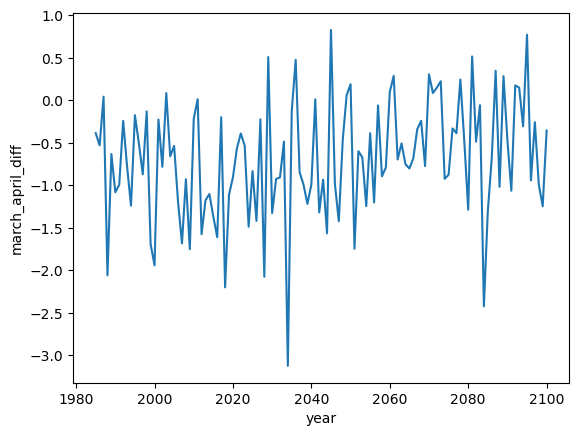

In [46]:
df_tmp = df_temp_march_april_diff.groupby('year')['march_april_diff'].min().reset_index()
sns.lineplot(data=df_tmp, x='year', y='march_april_diff')

Text(0.5, 1.0, 'Mean April - March Temperature Difference Over Years\nRCP8.5 Scenario, 40 runs, average ± SEM')

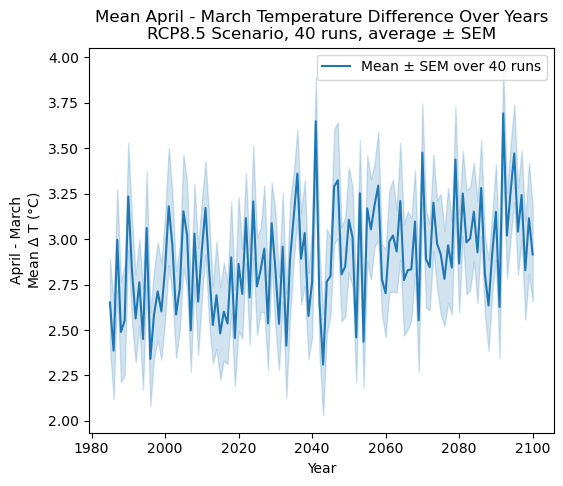

In [68]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = [ax]
sns.lineplot(data=df_temp_march_april_diff, x='year', y='march_april_diff', errorbar='se',
             ax=ax[0], label='Mean ± SEM over 40 runs')
# df_tmp = df_temp_march_april_diff.groupby('year')['march_april_diff'].min().reset_index()
# sns.lineplot(data=df_tmp, x='year', y='march_april_diff', ax=ax[0],
#              c='k', alpha=0.5, label='Min per year')

# df_tmp = df_temp_march_april_diff.groupby('year')['march_april_diff'].max().reset_index()
# sns.lineplot(data=df_tmp, x='year', y='march_april_diff', ax=ax[0],
#              c='k', alpha=0.5, label='Max per year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('April - March\nMean ' + r"$\Delta$ " + 'T (°C)')
ax[0].set_title('Mean April - March Temperature Difference Over Years\nRCP8.5 Scenario, 40 runs, average ± SEM')

In [162]:
dict_bb_cdf = posterior_predictions(posterior_samples, dict_df, infer_chilling=INFER_CHILLING, zoned_chilling=ZONED_CHILLING)

In [ ]:
## Calculate mid DOY for each season based on the mean temperature

# dict_temp_scen_results = {x: [] for x in ['year', 'mid_doy']}

# for i_s, s in enumerate(dict_df['test']['season'].unique()):
#     inds = np.where(dict_df['test']['season'] == s)[0]
#     sample_mean_year = dict_bb_cdf['sample_mean']['test'][:, inds]
#     doy_mid = np.argmin(np.abs(sample_mean_year.mean(0) - 0.5))
#     diff_temp = sample_mean_year.mean(0)[int(doy_mid)]
#     if diff_temp < 0.4:
#         dict_temp_scen_results['mid_doy'].append(np.nan)
#     else:    
#         dict_temp_scen_results['mid_doy'].append(int(doy_mid) + 1)  # +1 to convert from 0-based index to 1-based DOY

#     dict_temp_scen_results['year'].append(int(s.split('-')[1]))
    
# # df_split2 = pd.DataFrame(dict_temp_scen_results)
# df_split0 = pd.DataFrame(dict_temp_scen_results)

dict_temp_scen_results = {x: [] for x in ['year', 'mid_doy', 'doy_low_sd', 'doy_high_sd']}
for i_s, s in tqdm(enumerate(dict_df['test']['season'].unique())):
    mean_doy_mid_bb_est, error_doy_mid_bb_est, doy_mid_bb_obs, season = get_doy_errorbars(dict_bb_cdf, dict_df, ind_year=i_s, 
                                                                tt_use='test', bb_frac=0.5, scale_sigma_by_mu=True)
    dict_temp_scen_results['mid_doy'].append(mean_doy_mid_bb_est)
    dict_temp_scen_results['doy_low_sd'].append(error_doy_mid_bb_est[0])
    dict_temp_scen_results['doy_high_sd'].append(error_doy_mid_bb_est[1])
    dict_temp_scen_results['year'].append(int(s.split('-')[1]))

# df_split2 = pd.DataFrame(dict_temp_scen_results) 
df_split0 = pd.DataFrame(dict_temp_scen_results)

5it [00:12,  2.60s/it]


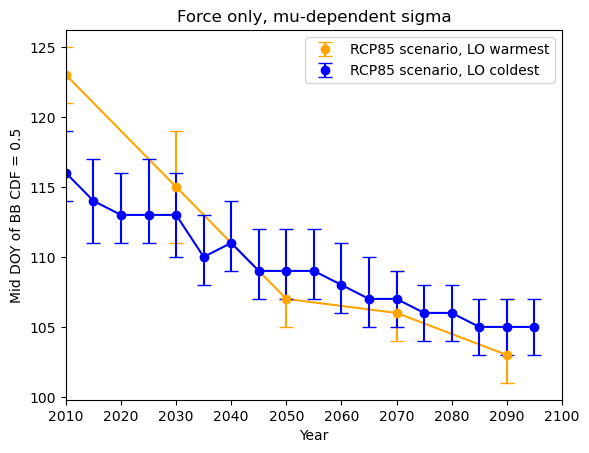

In [124]:
plt.errorbar(data=df_split0, x='year', y='mid_doy', 
             yerr=[df_split0['mid_doy'] - df_split0['doy_low_sd'], 
                   df_split0['doy_high_sd'] - df_split0['mid_doy']], 
             fmt='o', color='orange', label='RCP85 scenario, LO warmest', capsize=5)
sns.lineplot(data=df_split0, x='year', y='mid_doy', marker='o', color='orange', label='RCP85 scenario, LO warmest')

plt.errorbar(data=df_split2, x='year', y='mid_doy', 
             yerr=[df_split2['mid_doy'] - df_split2['doy_low_sd'], 
                   df_split2['doy_high_sd'] - df_split2['mid_doy']], 
             fmt='o', color='blue', label='RCP85 scenario, LO coldest', capsize=5)
sns.lineplot(data=df_split2, x='year', y='mid_doy', marker='o', color='blue', label='RCP85 scenario, LO coldest')

plt.xlabel('Year')
plt.ylabel('Mid DOY of BB CDF = 0.5')
plt.xlim(2010, 2100)
plt.title('Force only, mu-dependent sigma')

## only show first elements of legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
# plt.show()

In [ ]:
dict_df_temp_results = {}

for ind_member in tqdm(range(20)):
    print('scenario member', ind_member)
    df_temp_scen = get_tempererature_scenario(scenario='RCP85', average_temp_scenarios=False, ind_member=ind_member)
    # dict_df['test'] = create_test_df(df_temp_scen, years=list(range(2010, 2100, 5)))
    dict_df['test'] = create_test_df(df_temp_scen, years=np.random.choice(range(1985, 2100), size=15, replace=False))
    dict_bb_cdf = posterior_predictions(posterior_samples, dict_df, infer_chilling=INFER_CHILLING, zoned_chilling=ZONED_CHILLING)

    dict_temp_scen_results = {x: [] for x in ['year', 'mid_doy', 'doy_low_sd', 'doy_high_sd']}
    for i_s, s in tqdm(enumerate(dict_df['test']['season'].unique())):
        mean_doy_mid_bb_est, error_doy_mid_bb_est, doy_mid_bb_obs, season = get_doy_errorbars(dict_bb_cdf, dict_df, ind_year=i_s, 
                                                                    tt_use='test', bb_frac=0.5, scale_sigma_by_mu=True)
        dict_temp_scen_results['mid_doy'].append(mean_doy_mid_bb_est)
        dict_temp_scen_results['doy_low_sd'].append(error_doy_mid_bb_est[0])
        dict_temp_scen_results['doy_high_sd'].append(error_doy_mid_bb_est[1])
        dict_temp_scen_results['year'].append(int(s.split('-')[1]))

    dict_df_temp_results[ind_member] = pd.DataFrame(dict_temp_scen_results) 

In [159]:
for ind_member, df_temp_results in dict_df_temp_results.items():
    if ind_member == 0: 
        df_total_temp_scen = df_temp_results.copy()
    else:
        df_total_temp_scen = pd.concat([df_total_temp_scen, df_temp_results], ignore_index=True)

df_total_temp_scen['sd'] = (df_total_temp_scen['doy_high_sd'] - df_total_temp_scen['doy_low_sd'])
df_total_temp_scen['sd_inv'] = 1 / (df_total_temp_scen['sd'] + 1e-6)  # add small value to avoid division by zero

## weighted lin reg
from sklearn.linear_model import LinearRegression, LogisticRegression

model = LinearRegression()
# model = LogisticRegression()
X = df_total_temp_scen[['year']]
y = df_total_temp_scen['mid_doy']
weights = df_total_temp_scen['sd_inv']
print(X.shape, y.shape)
model.fit(X, y, sample_weight=weights)
model.coef_.shape, model.intercept_.shape

(300, 1) (300,)


((1,), ())

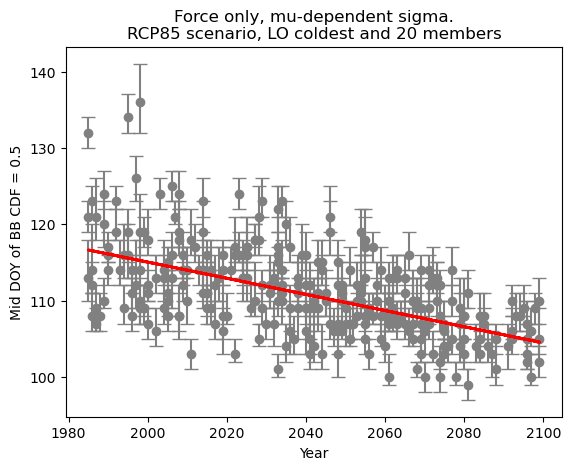

In [160]:
for ind_member, df_temp_results in dict_df_temp_results.items():
    plt.errorbar(data=df_temp_results, x='year', y='mid_doy', 
                yerr=[df_temp_results['mid_doy'] - df_temp_results['doy_low_sd'], 
                    df_temp_results['doy_high_sd'] - df_temp_results['mid_doy']], 
                    color='gray',
                fmt='o', label=f'RCP85 scenario (LO coldest), member {ind_member}', capsize=5)
    # sns.lineplot(data=df_temp_results, x='year', y='mid_doy', marker='o', color='gray',
    #               label=f'RCP85 scenario (LO coldest), member {ind_member}')

plt.plot(df_total_temp_scen['year'], model.predict(df_total_temp_scen[['year']]), color='red', linewidth=2, label='Weighted linear regression', zorder=10)

plt.xlabel('Year')
plt.ylabel('Mid DOY of BB CDF = 0.5')
# plt.xlim(2009, 2100)
plt.title(f'Force only, mu-dependent sigma.\nRCP85 scenario, LO coldest and {len(dict_df_temp_results)} members')

## only show first elements of legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# plt.legend(by_label.values(), by_label.keys())
# plt.show()

  0%|          | 0/3 [00:00<?, ?it/s]

No data provided -- using default data


/Users/tplas/repos/VeluweProtoDT/Py/src/dataloadermaker.py:34: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filePath)


No location list provided, using all locations
Training seasons: ['1998-1999', '1988-1989', '2003-2004', '2004-2005', '1992-1993', '1987-1988', '1994-1995', '2017-2018', '1991-1992', '2016-2017', '1993-1994', '2008-2009', '2015-2016', '2002-2003', '2011-2012', '2014-2015', '2000-2001', '1996-1997', '2020-2021', '1990-1991', '2009-2010', '2005-2006', '2012-2013', '1995-1996'], test seasons: ['2006-2007', '2013-2014', '2019-2020', '1989-1990', '2018-2019', '2021-2022', '2001-2002', '1997-1998', '1999-2000', '2022-2023', '2010-2011', '2007-2008']


 33%|███▎      | 1/3 [00:22<00:44, 22.09s/it]

...

No data provided -- using default data


/Users/tplas/repos/VeluweProtoDT/Py/src/dataloadermaker.py:34: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filePath)


No location list provided, using all locations
Training seasons: ['2006-2007', '2013-2014', '2019-2020', '1989-1990', '2018-2019', '2021-2022', '2001-2002', '1997-1998', '1999-2000', '2022-2023', '2010-2011', '2007-2008', '1998-1999', '1988-1989', '2003-2004', '2004-2005', '1992-1993', '1987-1988', '1994-1995', '2017-2018', '1991-1992', '2016-2017', '1993-1994', '2008-2009'], test seasons: ['2015-2016', '2002-2003', '2011-2012', '2014-2015', '2000-2001', '1996-1997', '2020-2021', '1990-1991', '2009-2010', '2005-2006', '2012-2013', '1995-1996']


100%|██████████| 3/3 [01:06<00:00, 22.33s/it]


Text(0.5, 1.0, 'Budburst data')

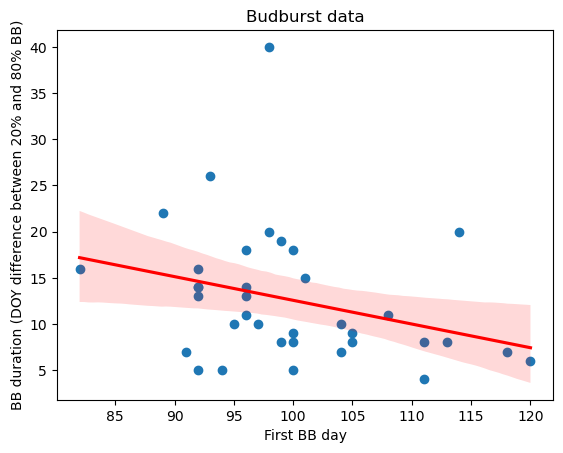

In [179]:
## BB duration

INFER_CHILLING = False
ZONED_CHILLING = False

dict_duration = {'season': [], 'duration_bb': [], 'mean_temp_march_may': [], 'first_doy_bb': []}


for ii in tqdm(range(3)):
    posterior_samples, dict_df = load_posterior_and_data(
        datetime_str_posterior='2025-07-16-2119',
        location_str='hoge-veluwe',
        split_n=ii,  # split to LOAD model from and to CREATE new data from
        n_splits=3,  # number of splits to CREATE new data from
        split_method='mean_temperature',
        get_train=False,  # return train data or not
        infer_chilling=INFER_CHILLING,
        zoned_chilling=ZONED_CHILLING
    )
    dict_bb_cdf = posterior_predictions(posterior_samples, dict_df, 
                                        infer_chilling=INFER_CHILLING, zoned_chilling=ZONED_CHILLING)

    n_seasons = 12
    for ind_year in range(n_seasons):
        mat_means, arr_stds, bb_cdf_obs, n_time_steps, season = get_means_std_from_posterior(dict_bb_cdf, 
                                                                                dict_df, tt_use='test', ind_year=ind_year)
        
        doy_bb_min = np.where(bb_cdf_obs > 0)[0][0]
        doy_bb_20 = np.argmin(np.abs(bb_cdf_obs - 0.2))
        doy_bb_80 = np.argmin(np.abs(bb_cdf_obs - 0.8))
        duration_bb = doy_bb_80 - doy_bb_20
        # print(f'Season {season}, BB duration (DOY 20 to 80%): {duration_bb} days')

        df_season = dict_df['test'][dict_df['test']['season'] == season]
        ## get mean temp march-may from date
        mean_temp_march_may = df_season[(df_season['doy'] >= 60) & (df_season['doy'] <= 151)]['temperature'].mean()

        dict_duration['season'].append(season)
        dict_duration['duration_bb'].append(duration_bb)
        dict_duration['mean_temp_march_may'].append(mean_temp_march_may)
        dict_duration['first_doy_bb'].append(doy_bb_min + 1)  # +1 to convert from 0-based index to 1-based DOY

df_duration = pd.DataFrame(dict_duration)
df_duration['year'] = df_duration['season'].apply(lambda x: int(x.split('-')[1]))
plt.scatter(data=df_duration, x='first_doy_bb', y='duration_bb')
sns.regplot(data=df_duration, x='first_doy_bb', y='duration_bb', scatter=False, color='red')
plt.xlabel('First BB day')
plt.ylabel('BB duration (DOY difference between 20% and 80% BB)')
plt.title('Budburst data')

100%|██████████| 12/12 [00:34<00:00,  2.86s/it]


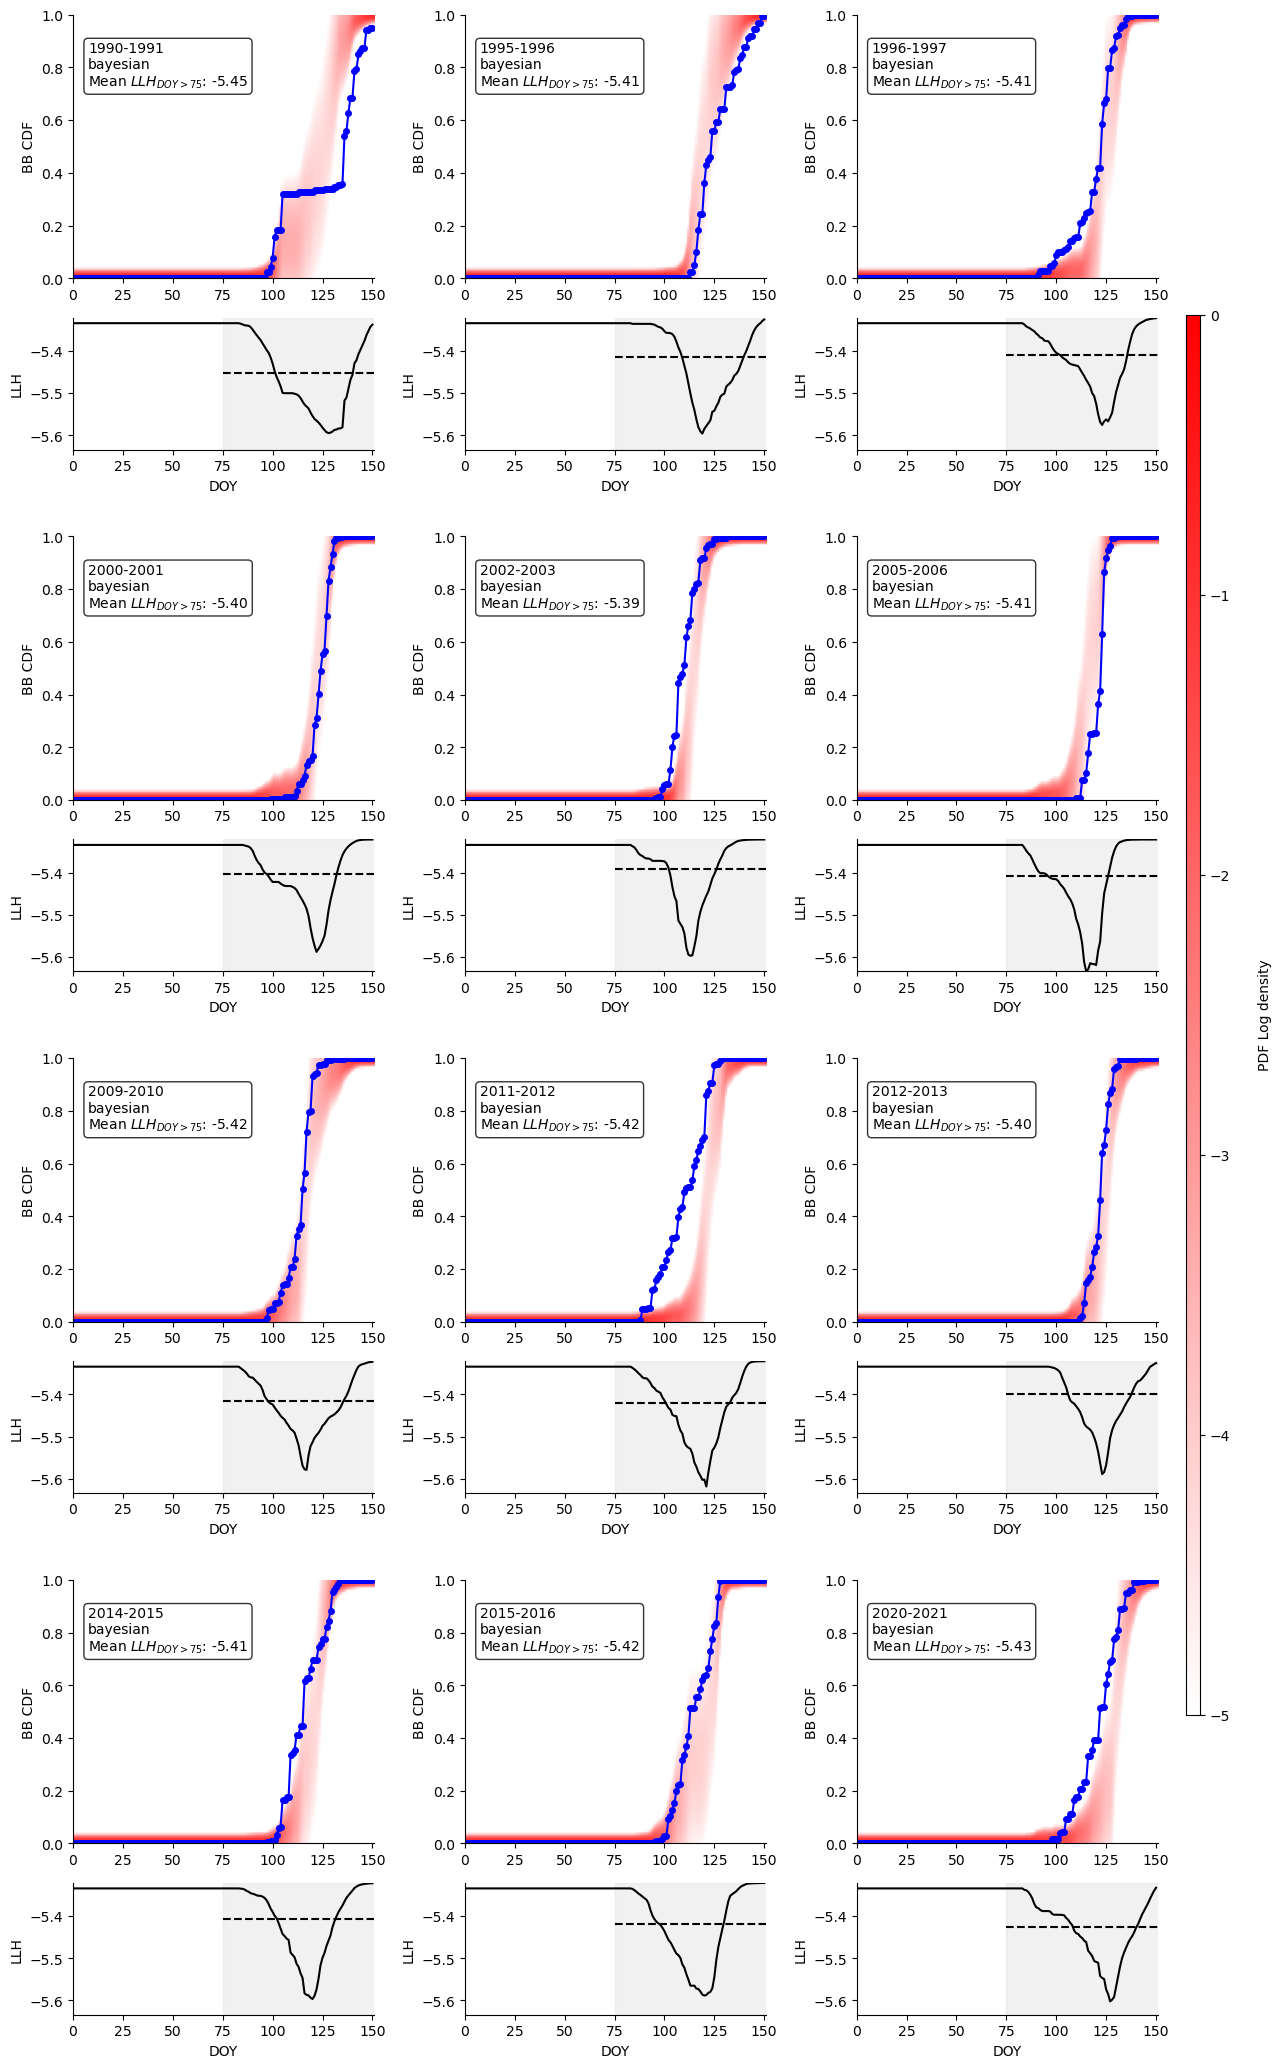

In [ ]:
def my_kde_bandwidth(obj, fac=1./0.1):
    """We use Scott's Rule, multiplied by a constant factor.
    https://docs.scipy.org/doc/scipy/tutorial/stats/kernel_density_estimation.html"""
    return np.power(obj.n, -1./(obj.d+4)) * fac

def get_means_std_from_posterior(dict_bb_cdf, dict_df, tt_use = 'test', ind_year=4):
                  
    n_time_steps = 151  # Number of time steps in a year (e.g., daily data for 151 days)
    ## n_time_steps = df_use["temperature"].values.shape / 6 
    ## n_time_steps = dict_bb_cdf['sample_mean'][tt].shape[1] / 6

    t_min = ind_year * n_time_steps
    t_max = (ind_year + 1) * n_time_steps
    mat_means = dict_bb_cdf['sample_mean'][tt_use][:, t_min:t_max]
    arr_stds = dict_bb_cdf['sample_std'][tt_use]
    bb_cdf_obs = dict_df[tt_use]['bb_cdf'][t_min:t_max].values

    season = dict_df[tt_use]['season'][t_min:t_max].values
    assert np.all(season == season[0]), f'All observations should be from the same season for this analysis. {season}'
    return mat_means, arr_stds, bb_cdf_obs, n_time_steps, season[0]

def compute_likelihood_gaussians(mat_means, arr_stds, arr_true, n_bins = 100, compute_pdf_sum=True, compute_kde=True,
                                 scale_sigma_by_mu=False):
    n_time_steps = mat_means.shape[1]  # Number of time steps
    list_methods = []
    assert compute_pdf_sum or compute_kde, "At least one method (pdf_sum or kde) must be True"
    if compute_pdf_sum:
        list_methods.append('bayesian')
    if compute_kde:
        list_methods.append('kde')
    mat_dens = {k: np.zeros((n_bins, n_time_steps)) for k in list_methods}
    arr_llh = {k: np.zeros(n_time_steps) for k in list_methods}
    for timestep in range(n_time_steps):
        mu = mat_means[:, timestep]  # shape (N_samples,)
        sigma = arr_stds  # shape (N_samples,)
        y_true = arr_true[timestep]
        eps = 1e-10  # Small value to avoid log(0)
        
        if compute_pdf_sum:
            # Evaluate M Gaussians at all y_grid points: shape (num_y, N_samples)
            y_grid = np.linspace(0, 1, n_bins)  # Assuming CDF values are between 0 and 1
            if scale_sigma_by_mu:
                # Scale sigma based on mu, to ensure it is larger for values close to 0.5
                sigma_scaled = (mu * (1 - mu)) ** 1 * sigma + 1e-2
            else:
                sigma_scaled = sigma
            pdfs = norm.pdf(y_grid[:, None], loc=mu, scale=sigma_scaled)
            density = pdfs.mean(axis=1)  # shape (num_y,)
            mat_dens['bayesian'][:, timestep] = density
            norm_bayesian = density.sum()
            mat_dens['bayesian'][:, timestep] /= norm_bayesian  # Normalize to ensure it sums to 1
            arr_llh['bayesian'][timestep] = np.log(np.mean(norm.pdf(y_true, loc=mu, scale=sigma) / norm_bayesian) + eps)  # Add small value to avoid log(0)
        
        if compute_kde:
            kde = gaussian_kde(mu, bw_method=my_kde_bandwidth)
            mat_dens['kde'][:, timestep] = kde(y_grid)
            norm_kde = mat_dens['kde'][:, timestep].sum()
            mat_dens['kde'][:, timestep] /= norm_kde  # Normalize to ensure it sums to 1
            arr_llh['kde'][timestep] = np.log(kde(y_true) / norm_kde + eps)  # Add small value to avoid log(0)
        
    return mat_dens, arr_llh, arr_true

def plot_likelihood(mat_dens, arr_llh, method, ax_pdf=None, ax_llh=None, print_mean_llh=True):
    if ax_pdf is None and ax_llh is None:
        fig, (ax_pdf, ax_llh) = plt.subplots(1, 2, figsize=(10, 5))
    else:
        fig = None
    cmap_density = sns.color_palette('blend:#fff,r', as_cmap=True)
    vmin, vmax = -5, 0
    n_time_steps = mat_dens[method].shape[1]
    name_dict = {'bayesian': 'Full PDF', 'kde': 'KDE of means'}
    assert method in mat_dens, f"Method {method} not found in mat_dens"
    if ax_pdf is not None:
        if method == 'bayesian':
            # plot_dens = mat_dens['bayesian'].copy()
            # for timestep in range(n_time_steps):
            #     max_density = np.max(plot_dens[:, timestep])
            #     plot_dens[:, timestep] /= max_density  # Normalize to ensure it is between 0 and 1
            # ax_pdf.imshow(plot_dens, aspect='auto', origin='lower', vmin=0, vmax=1,
            #                     cmap=cmap_density, extent=[0, n_time_steps, 0, 1])
            ax_pdf.imshow(np.log(mat_dens['bayesian'] + 1e-7), aspect='auto', origin='lower', vmin=vmin, vmax=vmax,
                                cmap=cmap_density, extent=[0, n_time_steps, 0, 1])
        else:
            assert False, 'Implement cbar return'
            ax_pdf.imshow(mat_dens[method], aspect='auto', origin='lower', cmap=cmap_density, 
                                    extent=[0, n_time_steps, 0, 1], vmax=np.percentile(mat_dens['kde'], 98))
        ax_pdf.set_title(name_dict[method])
    if ax_llh is not None:
        ax_llh.plot(arr_llh[method], label=f'{name_dict[method]} LLH', color='black', linewidth=1.5) 
        if print_mean_llh:
            ax_llh.annotate('Mean ' + r"$LLH_{DOY>75}$" + f'\n{method}: {arr_llh[method][75:].mean():.2f}',
                            xy=(0.05, 0.1), xycoords='axes fraction', fontsize=10,
                            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    return (fig, ax_pdf, ax_llh), (cmap_density, vmin, vmax)

def plot_all_methods_one_year(dict_bb_cdf, dict_df, ind_year=3, scale_sigma_by_mu=False):
    mat_means, arr_stds, bb_cdf_obs, n_time_steps, season = get_means_std_from_posterior(dict_bb_cdf, dict_df, tt_use='test', ind_year=ind_year)
    mat_dens, arr_llh, arr_true = compute_likelihood_gaussians(mat_means=mat_means, arr_stds=arr_stds, arr_true=bb_cdf_obs, 
                                                               compute_kde=True, compute_pdf_sum=True, scale_sigma_by_mu=scale_sigma_by_mu)
    n_methods = len(mat_dens)
    
    fig, ax = plt.subplots(2, n_methods, figsize=(4.5 * n_methods, 5), 
                        gridspec_kw={'wspace': 0.3, 'hspace': 0.2, 'height_ratios': [1, 0.5]})

    for i_method, method in enumerate(mat_dens.keys()):
        _, __ = plot_likelihood(mat_dens, arr_llh, method, ax_pdf=ax[0, i_method], ax_llh=ax[1, i_method])
        
    for a in ax[0, :]:
        a.plot(arr_true, label='Observed BB CDF', color='blue', linewidth=1.5)
        # a.set_xlabel('Time Steps (Days)')
        a.set_ylabel('BB CDF')
    ymin = min([a.get_ylim()[0] for a in ax[1, :]])
    ymax = max([a.get_ylim()[1] for a in ax[1, :]])
    for a in ax[1, :]:
        a.set_xlabel('Time Steps (Days)')
        a.set_ylabel('BB CDF')
        a.set_ylim(ymin, ymax)
    
    return (fig, ax), mat_dens

def plot_one_method_all_years(dict_bb_cdf, dict_df, method='bayesian', scale_sigma_by_mu=False):
    n_seasons = dict_df['test'].season.nunique()
    n_cols = 3
    n_double_rows = int(np.ceil(n_seasons / n_cols))

    fig = plt.figure(figsize=(14, 5 * n_double_rows))
    gs_list = []
    n_hor_breaks = n_double_rows - 1
    vertical_size_panel = 1 / (n_double_rows + n_hor_breaks * 0.2)  # Adjust vertical size for breaks
    vertical_size_break = 0.2 * vertical_size_panel
    assert n_double_rows * vertical_size_panel + n_hor_breaks * vertical_size_break == 1, f'Total height should be 1, got {n_double_rows * vertical_size_panel + n_hor_breaks * vertical_size_break}'
    for i in range(n_double_rows):
        gs_list.append(fig.add_gridspec(2, n_cols, height_ratios=[1, 0.5], hspace=0.2, wspace=0.3, 
                                        top=1 - i * (vertical_size_panel + vertical_size_break),
                                        bottom=1 - vertical_size_panel - i * (vertical_size_panel + vertical_size_break)))
        
    list_ax_pdf = [fig.add_subplot(gs_list[i][0, j]) for i in range(n_double_rows) for j in range(n_cols)]
    list_ax_llh = [fig.add_subplot(gs_list[i][1, j]) for i in range(n_double_rows) for j in range(n_cols)]

    min_day_llh_mean = 75
    max_day_llh_mean = None

    for ind_year in tqdm(range(n_seasons)):
        mat_means, arr_stds, bb_cdf_obs, n_time_steps, season = get_means_std_from_posterior(dict_bb_cdf, 
                                                                                dict_df, tt_use='test', ind_year=ind_year)
        if method == 'bayesian':
            mat_dens, arr_llh, arr_true = compute_likelihood_gaussians(mat_means=mat_means, 
                                arr_stds=arr_stds, arr_true=bb_cdf_obs, compute_kde=False, compute_pdf_sum=True,
                                scale_sigma_by_mu=scale_sigma_by_mu)
        else:
            assert False, f"Method {method} not implemented for this plot"
        if ind_year == 0:
            min_llh = arr_llh[method].min()
            max_llh = arr_llh[method].max()
        else:
            min_llh = min(min_llh, arr_llh[method].min())
            max_llh = max(max_llh, arr_llh[method].max())
        if max_day_llh_mean is None:
            max_day_llh_mean = n_time_steps

        ax_pdf = list_ax_pdf[ind_year] 
        ax_llh = list_ax_llh[ind_year]
        
        _, (cmap, vmin, vmax) = plot_likelihood(mat_dens, arr_llh=arr_llh, method=method, ax_pdf=ax_pdf, 
                                                ax_llh=ax_llh, print_mean_llh=False)
        mean_llh = arr_llh[method][min_day_llh_mean:max_day_llh_mean + 1].mean()
        ax_llh.set_ylabel('LLH')
        ax_llh.set_xlabel('DOY')
        ax_llh.set_ylim(-10, 0)
        ax_llh.plot([min_day_llh_mean, max_day_llh_mean], [mean_llh, mean_llh], 
                    color='black', linestyle='--', linewidth=1.5)

        ax_pdf.plot(arr_true, label='Observed BB CDF', color='blue', linestyle='-', 
                    markersize=4, marker='o', linewidth=1.5)
        ax_pdf.set_ylabel('BB CDF')
        assert min_day_llh_mean == 75, 'label currently for DOY > 75'
        ax_pdf.annotate(f'{season}\n{method}\nMean ' + r"$LLH_{DOY>75}$" + f': {mean_llh:.2f}', 
                        xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10, va='top',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax_pdf.set_title('')
        # return fig, (list_ax_pdf, list_ax_llh), (mat_dens, arr_llh)
    for a in list_ax_llh:
        a.set_xlim(0, n_time_steps)
        a.set_ylim(min_llh, max_llh)
        a.axvspan(min_day_llh_mean, max_day_llh_mean, color='lightgray', alpha=0.3)

    for a in list_ax_pdf + list_ax_llh:
        for sp in ['top', 'right']:
            a.spines[sp].set_visible(False)

    ## add colorbar for the PDF plots
    cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])  # [left, bottom, width, height]
    norm_cbar = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_cbar)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('PDF Log density', rotation=90, labelpad=20)            

    return fig, (list_ax_pdf, list_ax_llh), (mat_dens, arr_llh)
# plot_all_methods_one_year(ind_year=5)
tmp = plot_one_method_all_years(dict_bb_cdf, dict_df, method='bayesian', scale_sigma_by_mu=True)

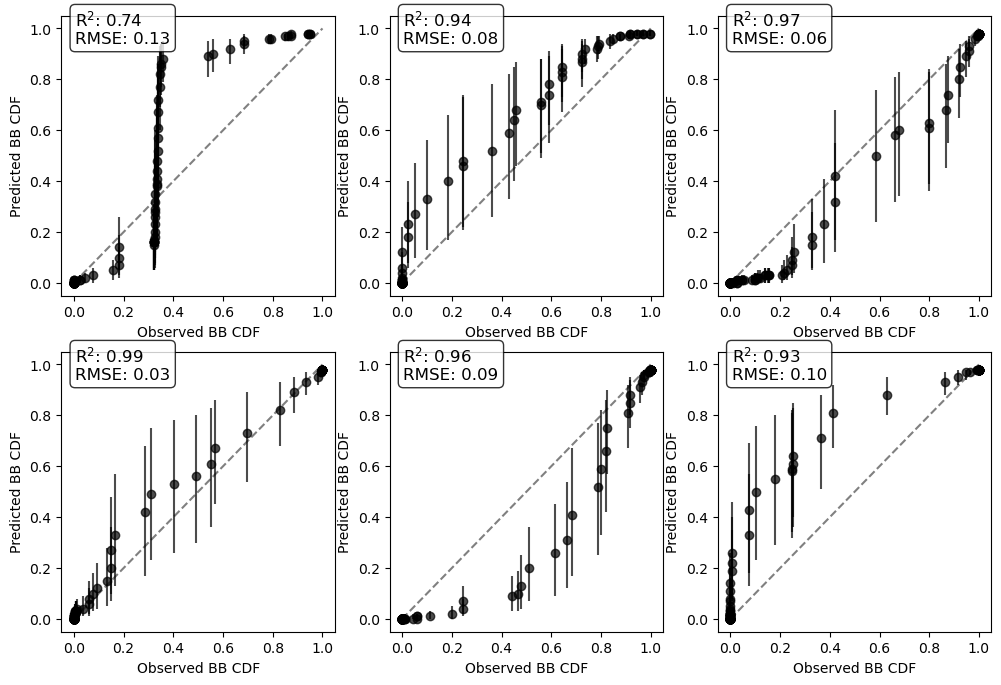

In [62]:

def get_errorbar(arr):
    assert len(arr.shape) == 1, 'Input should be a 1D array'
    assert np.isclose(np.sum(arr), 1), 'Input array should sum to 1'
    
    cum_arr = np.cumsum(arr)
    ind_median = np.argmin(np.abs(cum_arr - 0.5))
    ind_lower = np.argmin(np.abs(cum_arr - 0.16))
    ind_upper = np.argmin(np.abs(cum_arr - 0.84))

    return int(ind_lower), int(ind_median), int(ind_upper)

def get_bbcdf_errorbars(dict_bb_cdf, dict_df, ind_year=0, tt_use='test', 
                        scale_sigma_by_mu=True, normalise_to_percentage=False):
    mat_means, arr_stds, bb_cdf_obs, n_time_steps, season = get_means_std_from_posterior(dict_bb_cdf, dict_df, tt_use=tt_use, ind_year=ind_year)
    mat_dens, _, arr_true = compute_likelihood_gaussians(mat_means=mat_means, arr_stds=arr_stds, arr_true=bb_cdf_obs, 
                                                                compute_kde=False, compute_pdf_sum=True, scale_sigma_by_mu=scale_sigma_by_mu)

    arr_pred_median = np.zeros(n_time_steps)
    arr_pred_error = np.zeros((n_time_steps, 2))
    for timestep in range(n_time_steps):
        arr_pred_error[timestep, 0], arr_pred_median[timestep], arr_pred_error[timestep, 1] = get_errorbar(mat_dens['bayesian'][:, timestep])
    
    if normalise_to_percentage:
        arr_true = arr_true * 100
    else:
        arr_pred_error = arr_pred_error.astype(float) / 100
        arr_pred_median = arr_pred_median.astype(float) / 100

    return arr_pred_median, arr_pred_error, arr_true, season

def get_doy_errorbars(dict_bb_cdf, dict_df, ind_year=0, tt_use='test', bb_frac=0.5,
                        scale_sigma_by_mu=True):
    assert 0 <= bb_frac <= 1, 'bb_frac should be between 0 and 1'

    mat_means, arr_stds, bb_cdf_obs, n_time_steps, season = get_means_std_from_posterior(dict_bb_cdf, dict_df, tt_use=tt_use, ind_year=ind_year)
    mat_dens, _, arr_true = compute_likelihood_gaussians(mat_means=mat_means, arr_stds=arr_stds, arr_true=bb_cdf_obs, 
                                                                compute_kde=False, compute_pdf_sum=True, scale_sigma_by_mu=scale_sigma_by_mu)

    ## interpolate between time steps of arr_true to get DOY at which bb_frac is reached
    # inds_low = np.where(arr_true <= bb_frac)[0]
    # inds_high = np.where(arr_true >= bb_frac)[0]
    # if len(inds_low) == 0 or len(inds_high) == 0:
    #     assert False, f'bb_frac {bb_frac} not reached in year {season}'
    # val_max_low = arr_true[inds_low].max()
    # val_min_high = arr_true[inds_high].min()
    # assert val_max_low == arr_true[inds_low[-1]], f'val_max_low {val_max_low} should be equal to arr_true[inds_low[-1]] {arr_true[inds_low[-1]]}'
    # assert val_min_high == arr_true[inds_high[0]], f'val_min_high {val_min_high} should be equal to arr_true[inds_high[0]]'

    # if val_max_low == val_min_high:
    #     doy_true = inds_low[-1] + 1  # +1 to convert from 0-based index to 1-based DOY
    # else:
    #     doy_true = inds_low[-1] + (bb_frac - val_max_low) / (val_min_high - val_max_low)
    #     doy_true += 1  # +1 to convert from 0-based index to 1-based DOY

    doy_true = np.argmin(np.abs(arr_true - bb_frac)) + 1  # +1 to convert from 0-based index to 1-based DOY
    non_norm_dens_pred = mat_dens['bayesian'][49:51, :].mean(0)
    if non_norm_dens_pred.sum() < 1e-5:
        doy_pred_median = np.nan
        doy_pred_error = (np.nan, np.nan)
    else:
        norm_dens_pred_cdf = np.cumsum(non_norm_dens_pred / non_norm_dens_pred.sum())

        doy_pred_median = np.argmin(np.abs(norm_dens_pred_cdf - 0.5)) + 1
        doy_pred_error = (np.argmin(np.abs(norm_dens_pred_cdf - 0.26)) + 1, 
                          np.argmin(np.abs(norm_dens_pred_cdf - 0.84)) + 1)

    return doy_pred_median, doy_pred_error, doy_true, season

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
ax = ax.flatten()
for ind in range(6):
    arr_pred_median, arr_pred_error, arr_true, season = get_bbcdf_errorbars(dict_bb_cdf, dict_df, ind_year=ind, 
                                                            tt_use='test', scale_sigma_by_mu=True, normalise_to_percentage=False)
    
    curr_ax = ax[ind]
    curr_ax.plot([0, 1], [0, 1], color='gray', linestyle='--')
    curr_ax.errorbar(x=arr_true, y=arr_pred_median, yerr=[arr_pred_median - arr_pred_error[:, 0], 
                arr_pred_error[:, 1] - arr_pred_median], linestyle='', marker='o', label=ind, c='k', alpha=0.7)

    curr_ax.set_xlabel('Observed BB CDF')
    curr_ax.set_ylabel('Predicted BB CDF')

    rsme = np.sqrt(np.mean((arr_true - arr_pred_median) ** 2))
    r2 = r2_score(arr_true, arr_pred_median)
    curr_ax.annotate(f'R$^2$: {r2:.2f}\nRMSE: {rsme:.2f}', xy=(0.05, 0.9), xycoords='axes fraction', fontsize=12,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

In [64]:
mean_doy_mid_bb_est, error_doy_mid_bb_est, doy_mid_bb_obs, season = get_doy_errorbars(dict_bb_cdf, dict_df, ind_year=ind, 
                                                            tt_use='test', bb_frac=0.5, scale_sigma_by_mu=True)
mean_doy_mid_bb_est, error_doy_mid_bb_est, doy_mid_bb_obs, season

(np.int64(117), (np.int64(114), np.int64(120)), np.int64(123), '2005-2006')

(105.0, 120.0)

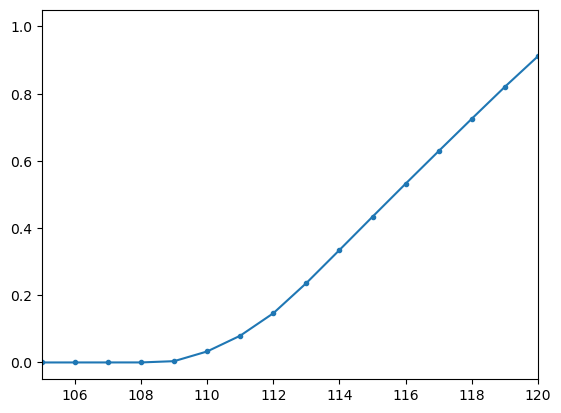

In [58]:
plt.plot(np.cumsum(tmp), '.-')
plt.xlim(105, 120)

In [61]:
np.argmin(np.abs(tmp - 0.5)) + 1, (np.argmin(np.abs(tmp - 0.26)) + 1,  np.argmin(np.abs(tmp - 0.84)) + 1)

(np.int64(116), (np.int64(116), np.int64(116)))

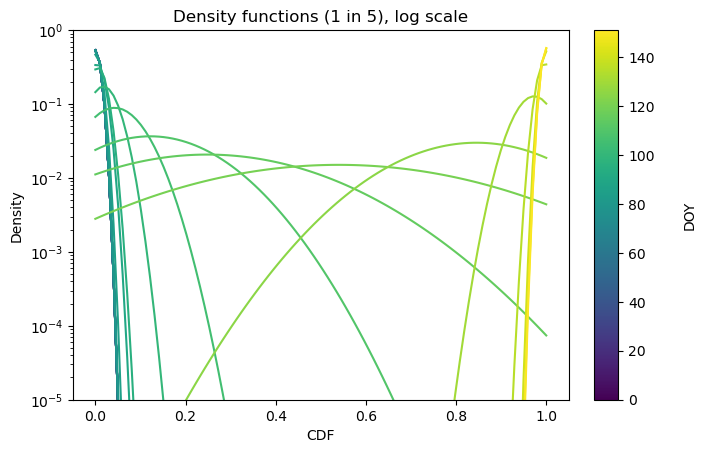

In [ ]:
# plt.imshow(mat_dens['bayesian'], origin='lower', aspect='auto', cmap='Reds', vmax=np.percentile(mat_dens['bayesian'], 90))
mat_dens = tmp[2][0]  # Get the density matrix for the Bayesian method
(n_dens, n_days) = mat_dens['bayesian'].shape

for id in range(n_days):
    c_id = plt.cm.viridis(id / n_days)  # Get a color from the viridis colormap
    line = mat_dens['bayesian'][:, id]
    # line = line / np.max(line)  # Normalize the line for better visibility 
    if id % 5 == 0:
        plt.plot(np.linspace(0, 1, n_dens), line, label=id, color=c_id, linewidth=1.5)
plt.xlabel('CDF')
plt.ylabel('Density')
plt.title('Density functions (1 in 5), log scale')
plt.yscale('log')
plt.ylim([1e-5, 1])  # Set y-axis limits for better visibility of the log scale

## add colorbar:
cbar_ax = plt.gca().inset_axes([1.05, 0, 0.05, 1])  # [left, bottom, width, height]
norm_cbar = plt.Normalize(vmin=0, vmax=n_days)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm_cbar)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label('DOY', rotation=90, labelpad=20)  # Add

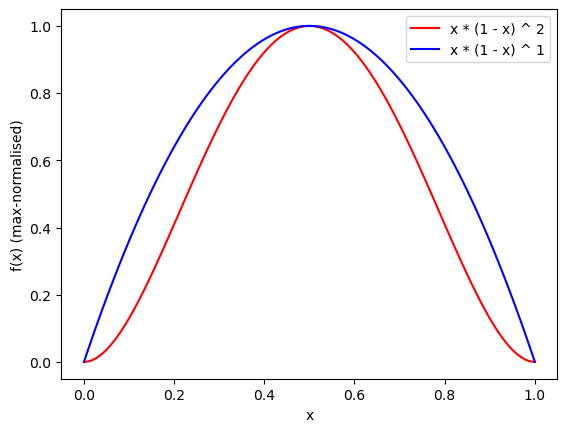

In [ ]:
x_arr = np.linspace(0, 1, 100)
# def f1(x, a):
#     return 1 - 2 * np.abs(x - 0.5) * a
def f2(x, a):
    return (x * (1 - x)) ** a

plt.plot(x_arr, f2(x_arr, 2) / f2(0.5, 2), label='x * (1 - x) ^ 2', color='red', linewidth=1.5)
plt.plot(x_arr, f2(x_arr, 1) / f2(0.5, 1), label='x * (1 - x) ^ 1', color='blue', linewidth=1.5)
plt.xlabel('x')
plt.ylabel('f(x) (max-normalised)')
plt.legend()

No data provided -- using default data
No location list provided, using all locations
Training seasons: ['1987-1988', '1988-1989', '1989-1990', '1990-1991', '1991-1992', '1992-1993', '1993-1994', '1994-1995', '1995-1996', '1996-1997', '1997-1998', '1998-1999', '1999-2000', '2000-2001', '2001-2002', '2002-2003', '2003-2004', '2004-2005', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023'], test seasons: ['2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011']


  0%|          | 0/151 [00:00<?, ?it/s]/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_57882/61455523.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  arr_llh['kde'][timestep] = np.log(kde(y_true) / norm_kde + eps)  # Add small value to avoid log(0)
  0%|          | 0/151 [00:00<?, ?it/s]/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_57882/61455523.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  arr_llh['kde'][timestep] = np.log(kde(y_true) / norm_kde + eps)  # Add small value to avoid log(0)
  0%|          | 0/151 [00:00<?, ?it/s]/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_57882/61455523.py:

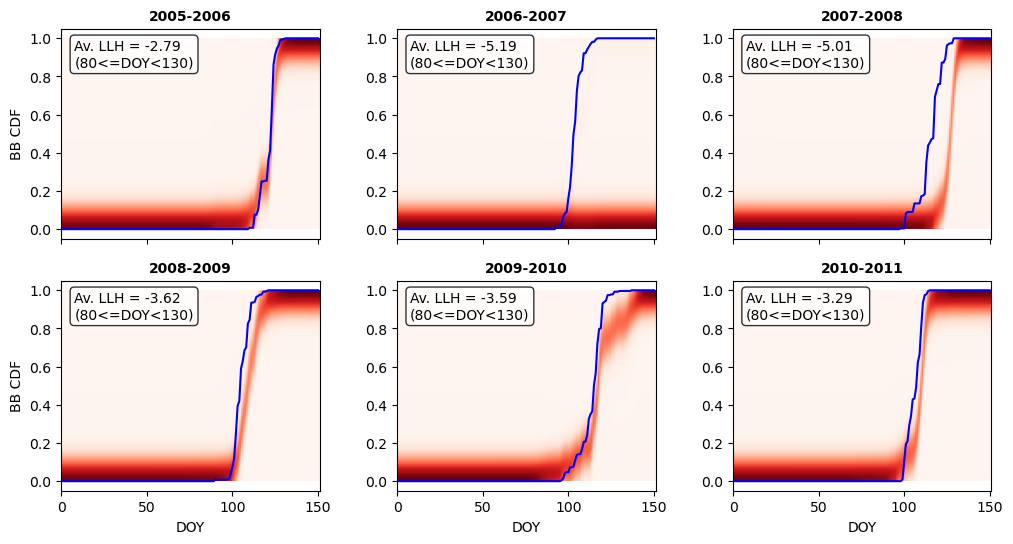

In [ ]:
def plot_all_years_in_split(dict_bb_cdf, dict_df, tt_use='test'):

    fig, ax = plt.subplots(2, 3, figsize=(12, 6),
                        gridspec_kw={'wspace': 0.3, 'hspace': 0.2})
    
    
    assert len(dict_df['test']['season'].unique()) == 6, f'dict_df should have 6 seasons, but has {len(dict_df["test"]["season"].unique())}'
    for ind_year in range(6):
        i_row, i_col = divmod(ind_year, 3)
        curr_ax = ax[i_row, i_col]
        mat_means, arr_stds, bb_cdf_obs, n_time_steps, season = get_means_std_from_posterior(dict_bb_cdf, dict_df, tt_use=tt_use, ind_year=ind_year)
        mat_dens, arr_llh, arr_true = compute_likelihood_gaussians(mat_means=mat_means, arr_stds=arr_stds, arr_true=bb_cdf_obs)
        plot_likelihood_compact(mat_dens, arr_llh, arr_true, llh_method='bayesian', ax=curr_ax)
        curr_ax.set_title(f'{season}', fontsize=10, weight='bold')

        if i_row == 0:
            curr_ax.set_xlabel('')
            curr_ax.set_xticklabels([])
        if i_col != 0:
            curr_ax.set_ylabel('')

posterior_samples, dict_df = load_posterior_and_data(
    datetime_str_posterior='2025-05-27-0949',
    split_n=3,
    get_train=False,
    infer_chilling=True,
    zoned_chilling=True, 
    location_str='hoge-veluwe'  # Specify the location if needed
)
dict_bb_cdf = posterior_predictions(posterior_samples, dict_df, infer_chilling=True, zoned_chilling=True)
plot_all_years_in_split(dict_bb_cdf, dict_df, tt_use='test')

In [ ]:
ds_mean_llh = {x: [] for x in ['bayesian', 'kde', 'bayesian_kde_threshold', 'datetime_str', 'split_n', 'ind_year', 'season', 'year']}
time_av = slice(80, 130)  # Time steps after DOY 75

for datetime_str_posterior in ['2025-05-27-0949', '2025-05-27-0952']:  # Example datetime string for the posterior file
    location_str = 'hoge-veluwe' if datetime_str_posterior == '2025-05-27-0949' else 'all-locations'
    for split_n in tqdm(range(6)):
        posterior_samples, dict_df = load_posterior_and_data(
            datetime_str_posterior=datetime_str_posterior,
            split_n=split_n,
            location_str=location_str,
            get_train=False,
            infer_chilling=True,
            zoned_chilling=True
        )
        dict_bb_cdf = posterior_predictions(posterior_samples, dict_df, infer_chilling=True, zoned_chilling=True)
        for ind_year in range(6):
            mat_means, arr_stds, bb_cdf_obs, n_time_steps, season = get_means_std_from_posterior(dict_bb_cdf, dict_df, tt_use='test', ind_year=ind_year)
            mat_dens, arr_llh, arr_true = compute_likelihood_gaussians(mat_means=mat_means, arr_stds=arr_stds, arr_true=bb_cdf_obs)

            ds_mean_llh['bayesian'].append(arr_llh['bayesian'][time_av].mean())
            ds_mean_llh['kde'].append(arr_llh['kde'][time_av].mean())
            ds_mean_llh['bayesian_kde_threshold'].append(arr_llh['bayesian_kde_threshold'][time_av].mean())
            ds_mean_llh['datetime_str'].append(datetime_str_posterior)
            ds_mean_llh['split_n'].append(split_n)
            ds_mean_llh['ind_year'].append(ind_year)
            ds_mean_llh['season'].append(season)
            ds_mean_llh['year'].append(int(season.split('-')[1]))
        
df_mean_llh = pd.DataFrame(ds_mean_llh)
df_mean_llh

  0%|          | 0/6 [00:00<?, ?it/s]

No data provided -- using default data
No location list provided, using all locations
Training seasons: ['1993-1994', '1994-1995', '1995-1996', '1996-1997', '1997-1998', '1998-1999', '1999-2000', '2000-2001', '2001-2002', '2002-2003', '2003-2004', '2004-2005', '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023'], test seasons: ['1987-1988', '1988-1989', '1989-1990', '1990-1991', '1991-1992', '1992-1993']


/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_57882/61455523.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  arr_llh['kde'][timestep] = np.log(kde(y_true) / norm_kde + eps)  # Add small value to avoid log(0)
 17%|█▋        | 1/6 [00:33<02:47, 33.46s/it]

No data provided -- using default data
No location list provided, using all locations
Training seasons: ['1987-1988', '1988-1989', '1989-1990', '1990-1991', '1991-1992', '1992-1993', '1999-2000', '2000-2001', '2001-2002', '2002-2003', '2003-2004', '2004-2005', '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023'], test seasons: ['1993-1994', '1994-1995', '1995-1996', '1996-1997', '1997-1998', '1998-1999']


/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_57882/61455523.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  arr_llh['kde'][timestep] = np.log(kde(y_true) / norm_kde + eps)  # Add small value to avoid log(0)
 33%|███▎      | 2/6 [01:07<02:15, 33.81s/it]

...

No data provided -- using default data
No location list provided, using all locations
Training seasons: ['1987-1988', '1988-1989', '1989-1990', '1990-1991', '1991-1992', '1992-1993', '1993-1994', '1994-1995', '1995-1996', '1996-1997', '1997-1998', '1998-1999', '1999-2000', '2000-2001', '2001-2002', '2002-2003', '2003-2004', '2004-2005', '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023'], test seasons: ['2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017']


/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_57882/61455523.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  arr_llh['kde'][timestep] = np.log(kde(y_true) / norm_kde + eps)  # Add small value to avoid log(0)
 83%|████████▎ | 5/6 [02:57<00:35, 35.63s/it]

No data provided -- using default data
No location list provided, using all locations
Training seasons: ['1987-1988', '1988-1989', '1989-1990', '1990-1991', '1991-1992', '1992-1993', '1993-1994', '1994-1995', '1995-1996', '1996-1997', '1997-1998', '1998-1999', '1999-2000', '2000-2001', '2001-2002', '2002-2003', '2003-2004', '2004-2005', '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017'], test seasons: ['2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023']


/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_57882/61455523.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  arr_llh['kde'][timestep] = np.log(kde(y_true) / norm_kde + eps)  # Add small value to avoid log(0)
100%|██████████| 6/6 [03:33<00:00, 35.53s/it]


,bayesian,kde,bayesian_kde_threshold,datetime_str,split_n,ind_year,season,year
0,-3.256820,-2.842040,-3.256820,2025-05-27-0949,0,0,1987-1988,1988
1,-5.168582,-9.762478,-9.668959,2025-05-27-0949,0,1,1988-1989,1989
2,-5.390512,-4.515386,-5.390512,2025-05-27-0949,0,2,1989-1990,1990
3,-6.045689,-6.100579,-6.045689,2025-05-27-0949,0,3,1990-1991,1991
4,-3.822387,-5.421180,-3.822387,2025-05-27-0949,0,4,1991-1992,1992
...,...,...,...,...,...,...,...,...
67,-3.727079,-3.495146,-3.727079,2025-05-27-0952,5,1,2018-2019,2019
68,-4.176443,-3.438330,-4.176443,2025-05-27-0952,5,2,2019-2020,2020
69,-3.612933,-4.684784,-3.612933,2025-05-27-0952,5,3,2020-2021,2021
70,-3.452091,-4.793490,-3.452091,2025-05-27-0952,5,4,2021-2022,2022


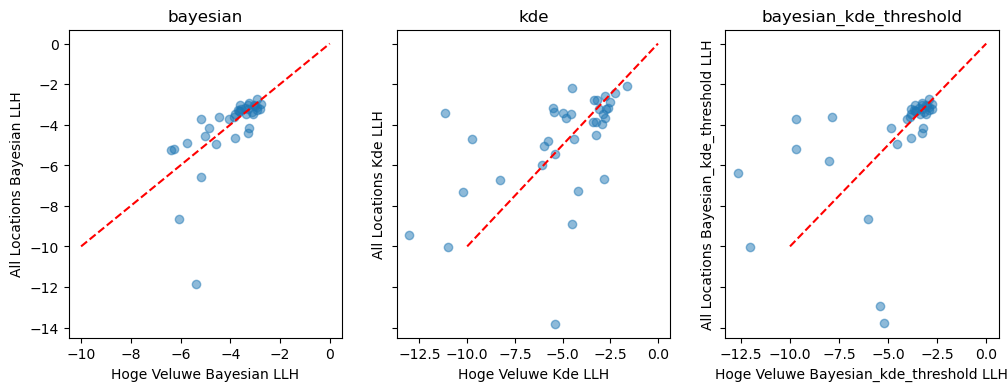

In [ ]:
## Create a pivot table that has a value ofr bayesian for each season, split by datetime_str 

df_pivot = df_mean_llh.pivot_table(index=['season', 'year'],
                                   columns='datetime_str',
                                   values=['bayesian', 'kde', 'bayesian_kde_threshold'],
                                   aggfunc='mean').reset_index()
# df_pivot
datetime_str_list = [x for x in df_pivot.columns.levels[1].unique() if x != '']
assert len(datetime_str_list) == 2, f"Expected 2 datetime strings, but found {datetime_str_list}"

## scatter plot datetime_str_list[0] vs datetime_str_list[1] (of bayesian, kde, bayesian_kde_threshold) 
label_datetime_dict = {'2025-05-27-0949': 'Hoge Veluwe', '2025-05-27-0952': 'All Locations'}
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for i, llh_type in enumerate(['bayesian', 'kde', 'bayesian_kde_threshold']):
    ax[i].scatter(df_pivot[llh_type][datetime_str_list[0]], df_pivot[llh_type][datetime_str_list[1]], alpha=0.5)
    ax[i].set_xlabel(f'{label_datetime_dict[datetime_str_list[0]]} {llh_type.capitalize()} LLH')
    ax[i].set_ylabel(f'{label_datetime_dict[datetime_str_list[1]]} {llh_type.capitalize()} LLH')
    ax[i].set_title(llh_type)
    ax[i].plot([-10, 0], [-10, 0], color='red', linestyle='--')  # Diagonal line for reference
    

<Axes: xlabel='year', ylabel='kde'>

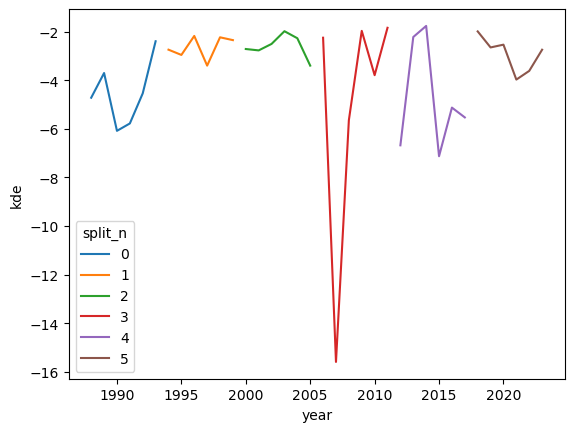

In [ ]:
sns.lineplot(data=df_mean_llh, x='year', y='kde', hue='split_n', palette='tab10')

(-5.0, -2.0)

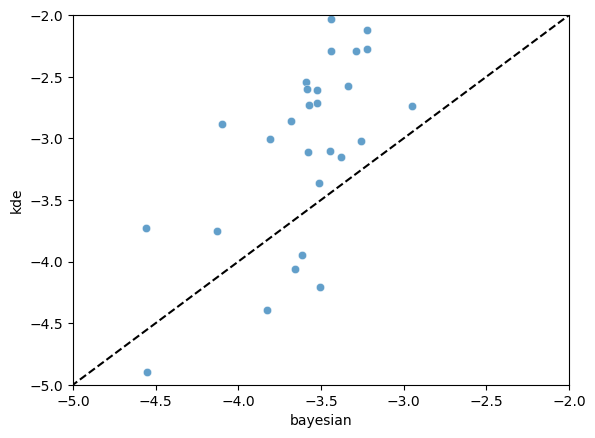

In [ ]:
import seaborn as sns
sns.scatterplot(data=df_mean_llh, x='bayesian', y='kde', alpha=0.7)
plt.plot([-16, 0], [-16, 0], color='black', linestyle='--')
plt.xlim(-5, -2)
plt.ylim(-5, -2)

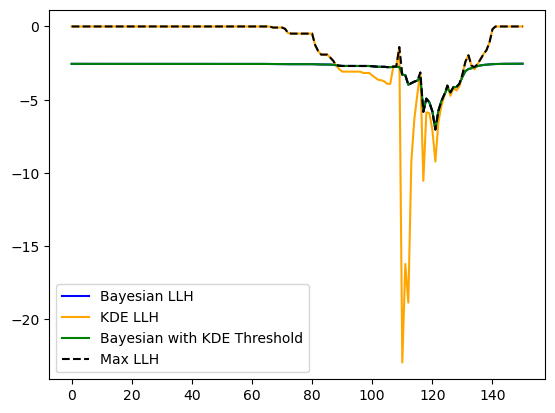

In [ ]:
plt.plot(arr_llh['bayesian'], label='Bayesian LLH', color='blue', linewidth=1.5, linestyle='-')
plt.plot(arr_llh['kde'], label='KDE LLH', color='orange', linewidth=1.5, linestyle='-')
plt.plot(arr_llh['bayesian_kde_threshold'], label='Bayesian with KDE Threshold', color='green', linewidth=1.5, linestyle='-')
plt.plot(np.maximum(arr_llh['bayesian'], arr_llh['kde']), label='Max LLH', color='black', linewidth=1.5, linestyle='--')
plt.legend()

BB mean and std: 0.885, 0.032
Data 0.9167 with likelihood: 5.244


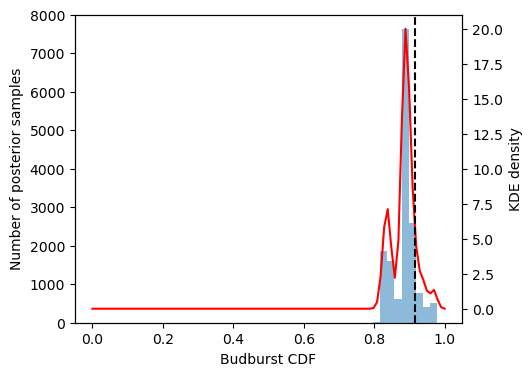

In [ ]:
id = 125
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(bb_cdf_samples[:, id], bins=np.linspace(0, 1, 50), density=False, alpha=0.5)
print(f'BB mean and std: {np.mean(bb_cdf_samples[:, id]):.3f}, {np.std(bb_cdf_samples[:, id]):.3f}')
ax.set_ylabel('Number of posterior samples')
## plot gaussian KDE using scipy
from scipy.stats import gaussian_kde
def my_kde_bandwidth(obj, fac=1./0.5):
    """We use Scott's Rule, multiplied by a constant factor.
    https://docs.scipy.org/doc/scipy/tutorial/stats/kernel_density_estimation.html"""
    return np.power(obj.n, -1./(obj.d+4)) * fac
kde = gaussian_kde(bb_cdf_samples[:, id], bw_method=my_kde_bandwidth)
ax2 = ax.twinx()
x = np.linspace(0, 1, 100)
ax2.plot(x, kde(x), label='KDE', color='red')
ax2.set_ylabel('KDE density')
ax.set_xlabel('Budburst CDF')
ax2.axvline(df_test.bb_cdf.values[id], color='black', linestyle='--', label='Mean BB CDF')
## Compute log likelihood for the posterior samples using the KDE
log_likelihood = kde(df_test.bb_cdf.values[id])[0]
print(f'Data {df_test.bb_cdf.values[id]:.4f} with likelihood: {log_likelihood:.3f}')

/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_26975/3715632166.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  arr_llh[i_id] = np.log(kde(df_test.bb_cdf.values[id]) + eps)  # Add small value to avoid log(0)


Mean log likelihood: 2.916


Text(0, 0.5, 'Budburst CDF')

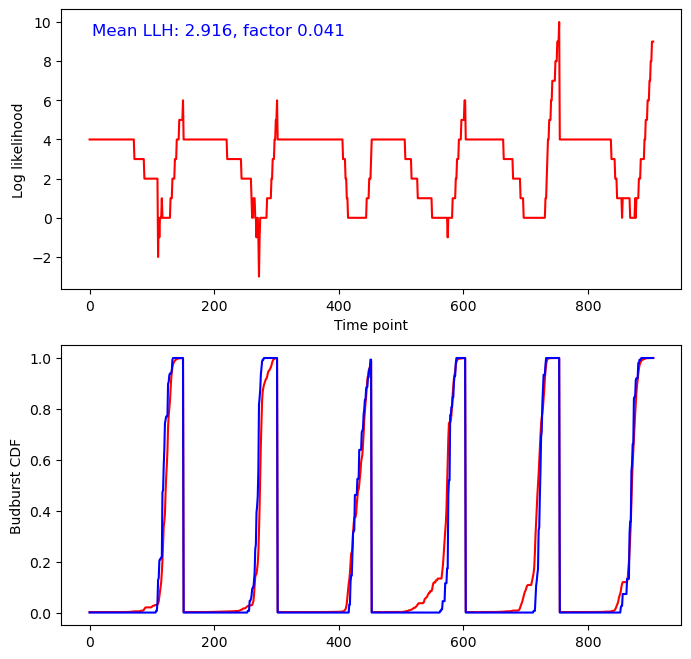

In [ ]:
## plot the LLH estimated via KDE per time point as a function of time
fig, ax = plt.subplots(2, 1, figsize=(8, 8))

def calculate_llh(bb_cdf_samples, df_test, fac_bw_gauss=0.2, eps=1e-10):
    """Calculate log likelihood for each time point using Gaussian KDE."""
    arr_timepoints = np.arange(bb_cdf_samples.shape[1])  # Time points (0 to n_test-1)
    arr_llh = np.zeros_like(arr_timepoints)
    for i_id, id in enumerate(arr_timepoints):
        kde = gaussian_kde(bb_cdf_samples[:, id], bw_method=lambda x: my_kde_bandwidth(x, fac=1./fac_bw_gauss))
        arr_llh[i_id] = np.log(kde(df_test.bb_cdf.values[id]) + eps)  # Add small value to avoid log(0)
    return arr_timepoints, arr_llh

fac_bw_gauss = 0.041  # Factor for bandwidth of Gaussian KDE
arr_timepoints, arr_llh = calculate_llh(bb_cdf_samples, df_test, fac_bw_gauss=fac_bw_gauss)
mean_llh = np.mean(arr_llh)
print(f'Mean log likelihood: {mean_llh:.3f}')
ax1 = ax[0]
ax1.plot(arr_timepoints, arr_llh, label='Log likelihood', color='red')
ax1.annotate(f'Mean LLH: {mean_llh:.3f}, factor {fac_bw_gauss}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, color='blue', ha='left', va='top')
ax1.set_xlabel('Time point')
ax1.set_ylabel('Log likelihood')

# ax2 = ax.twinx()
ax2 = ax[1]
ax2.plot(arr_timepoints, bb_cdf_mean, label='Mean prediction', color='red')
ax2.plot(arr_timepoints, df_test.bb_cdf.values, label='Observed BB CDF', color='blue')
ax2.set_ylabel('Budburst CDF')

Max LLH for train dataset at factor 0.041 with value 3.020
Max LLH for test dataset at factor 0.045 with value 2.932


Text(0, 0.5, 'Mean log likelihood')

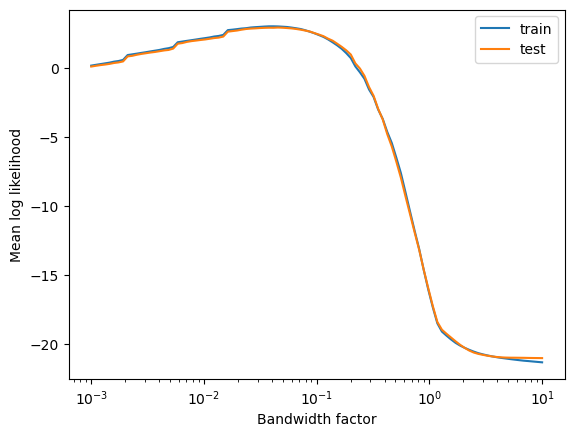

In [ ]:
fac = np.logspace(-3, 1, 100)
# llh_mean = {k: np.zeros_like(fac) for k in ['train', 'test']}
ax = plt.subplot(111)

for tt, bb_cdf_samples in dict_bb_cdf['samples'].items():
#     print(f'Calculating log likelihood for {tt} dataset...')
#     for i_f, f in tqdm(enumerate(fac)):
#         _, llh = calculate_llh(bb_cdf_samples, df_test if tt == 'test' else df_train, fac_bw_gauss=f)
#         llh_mean[tt][i_f] = np.mean(llh)

    ax.plot(fac, llh_mean[tt], label=tt)

    ## print arg max
    arg_max = np.argmax(llh_mean[tt])
    print(f'Max LLH for {tt} dataset at factor {fac[arg_max]:.3f} with value {llh_mean[tt][arg_max]:.3f}')
ax.set_xscale('log')
ax.set_xlabel('Bandwidth factor')
ax.legend()
ax.set_ylabel('Mean log likelihood')

array([[<Axes: ylabel='alpha'>, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta'>, <Axes: >, <Axes: >],
       [<Axes: xlabel='alpha', ylabel='sigma'>, <Axes: xlabel='beta'>,
        <Axes: xlabel='sigma'>]], dtype=object)

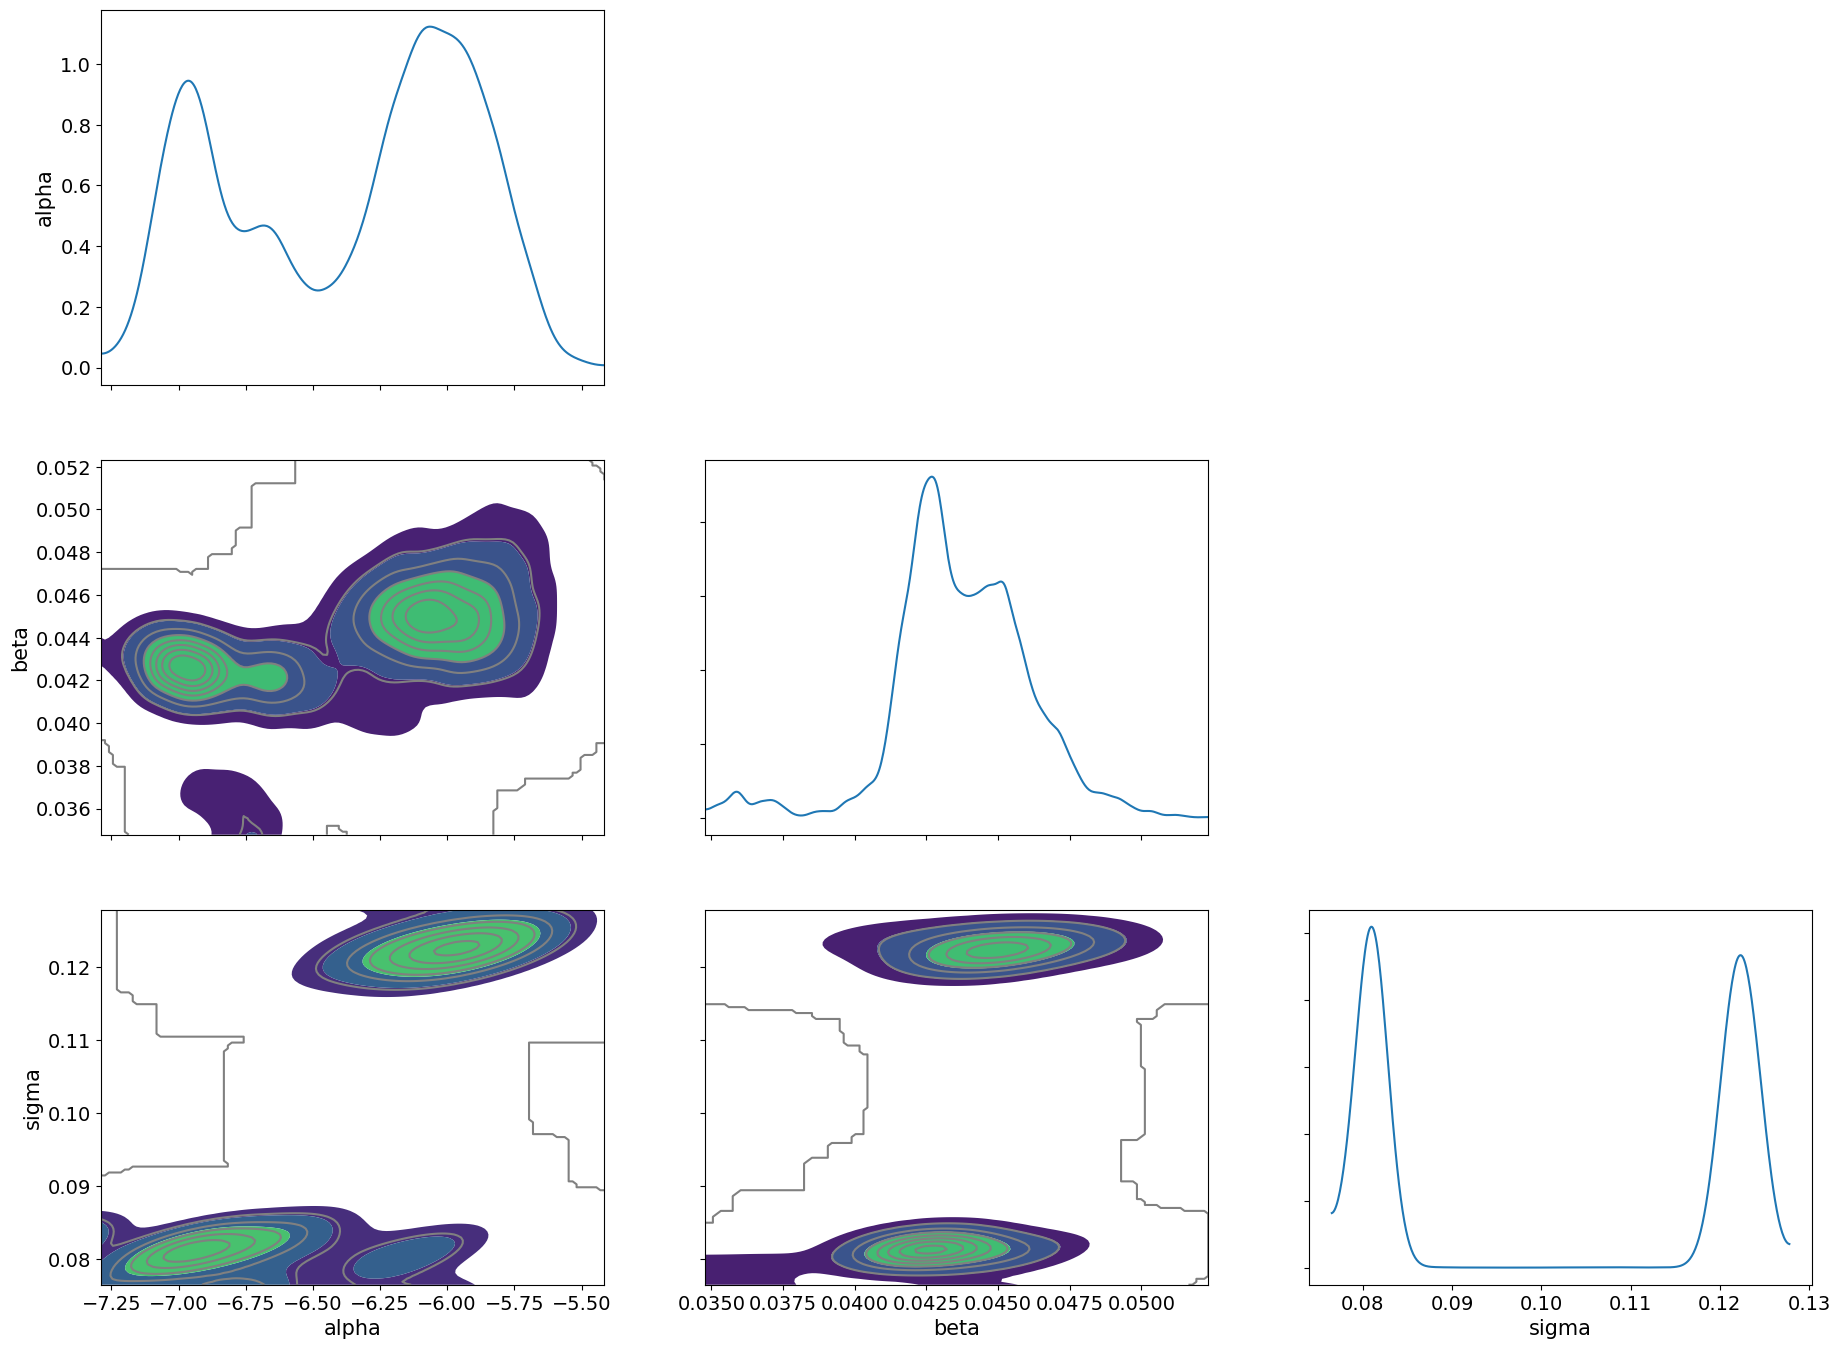

In [ ]:
az.plot_pair(posterior_samples, var_names=['alpha', 'beta', 'sigma'], kind='kde', marginals=True)


In [ ]:
# plt.hist(posterior_samples.log_likelihood.bb_cdf[0, 0, :])
# pm.model_to_graphviz(model)
az.loo(posterior_samples)

/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.47 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 80 posterior samples and 4530 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -3636.17    67.30
p_loo     1507.44        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.47]   (good)     3854   85.1%
   (0.47, 1]   (bad)       344    7.6%
   (1, Inf)   (very bad)  332    7.3%

In [ ]:

with model:
    pm.model.set_data({'temperature': df_test['temperature'].values})
    pp = pm.sample_posterior_predictive(posterior_samples, predictions=True, var_names=['bb_cdf'])

In [ ]:
axes = az.plot_pair(posterior_samples, var_names=['t_base_force', 't_base_chill', 't_bottom_chill'], 
             kind='kde', colorbar=True, gridsize=10, marginals=True, figsize=(10, 10),
             point_estimate='mean')

# # Get the figure from one of the axes
# fig = axes[0, 0].figure

# # Find the colorbar and relabel it
# # Assuming only one colorbar exists (typical for az.plot_pair)
# for ax in fig.axes:
#     if hasattr(ax, 'get_ylabel') and ax.get_ylabel() == '':
#         cbar = ax
#         print("Found colorbar axis:", cbar.get_yticklabels())
#         # break

# # Remove 'low' and 'high', add numeric ticks
# cbar.set_yticklabels([f"{tick:.2f}" for tick in cbar.get_yticks()])

In [ ]:
posterior = az.extract(posterior_samples)
df_use = df_test
infer_chilling = True

# Extract posterior samples (e.g., 1000 samples)
n_samples = len(posterior["t_base_force"])  # Number of posterior samples
temperature_test = df_use["temperature"].values
n_test = len(temperature_test)  # Number of test observations

# Initialize array to store GDD predictions (n_samples x n_test)
gdd_samples = np.zeros((n_samples, n_test))

for i in range(n_samples):
    t_base_force_sample = float(posterior["t_base_force"][i].values)
    if infer_chilling:
        t_base_chill_sample = float(posterior["t_base_chill"][i].values)
        threshold_cum_chill_sample = float(posterior["threshold_cum_chill"][i].values)
    else:
        start_doy_sample = float(posterior["start_date"][i].values)

    t_above_base_test = np.maximum(0, temperature_test - t_base_force_sample)

    gdd_test = np.zeros_like(t_above_base_test)
    for s in df_use["season"].unique():
        inds_s = df_use["season"] == s
        inds_s = inds_s.values
        doy_s = df_use["doy"][inds_s].values

        if infer_chilling:
            # cum_chill_days = pt.where(temperature_test[inds_s] < t_base_chill_sample, 1, 0)
            # cum_chill_days = pt.cumsum(cum_chill_days)
            cum_chill_days = np.zeros_like(doy_s)
            cum_chill_days[temperature_test[inds_s] < t_base_chill_sample] = 1
            cum_chill_days = np.cumsum(cum_chill_days)

            # Calculate GDD for the current season
            gdd_s = t_above_base_test[inds_s]
            gdd_s[cum_chill_days < threshold_cum_chill_sample] = 0
        else:
            gdd_s = t_above_base_test[inds_s]
            gdd_s[doy_s < start_doy_sample] = 0  # Set GDD to 0 before start date
        gdd_s = np.cumsum(gdd_s)  # Compute cumulative sum
        gdd_test[inds_s] = gdd_s

    gdd_samples[i, :] = gdd_test  # Store sample-specific GDD

# Initialize array for predictions (n_samples x n_test)
bb_cdf_samples = np.zeros((n_samples, n_test))
for i in range(n_samples):
    alpha_sample = float(posterior["alpha"][i].values)
    beta_sample = float(posterior["beta"][i].values)
    
    # Logistic function: maps GDD to cumulative fraction
    # bb_cdf_samples[i, :] = 1 / (1 + np.exp(-( beta_sample * gdd_samples[i, :])))
    bb_cdf_samples[i, :] = 1 / (1 + np.exp(-(alpha_sample + beta_sample * gdd_samples[i, :])))

bb_cdf_mean = np.mean(bb_cdf_samples, axis=0)  # Mean prediction
bb_cdf_lower = np.percentile(bb_cdf_samples, 0.5, axis=0)  # 2.5th percentile (lower CI)
bb_cdf_upper = np.percentile(bb_cdf_samples, 99.5, axis=0)  # 97.5th percentile (upper CI)

df_use["predicted_bb_cdf"] = bb_cdf_mean
df_use["bb_cdf_lower"] = bb_cdf_lower
df_use["bb_cdf_upper"] = bb_cdf_upper

fig, ax = plt.subplots(figsize=(12, 6), nrows=2, ncols=3, gridspec_kw={"hspace": 0.4, "wspace": 0.8})

for i_s, s in enumerate(df_use['season'].unique()):
    tmp_sel = df_use[df_use['season'] == s]
    curr_ax = np.ravel(ax)[i_s]

    curr_ax.plot(tmp_sel.doy, tmp_sel.temperature, '.', c='k', markersize=2)

    ax2 = curr_ax.twinx()
    ax2.plot(tmp_sel.doy, tmp_sel.predicted_bb_cdf, 'r-', lw=2)
    ax2.plot(tmp_sel.doy, tmp_sel.bb_cdf, 'b-', lw=1)
    ## uncertainty:
    ax2.fill_between(x=tmp_sel.doy, y1=tmp_sel.bb_cdf_lower, y2=tmp_sel.bb_cdf_upper, color='red', alpha=0.4)

    curr_ax.annotate(s, xy=(0.05, 0.9), xycoords='axes fraction', ha='left', va='center', weight='bold')
    curr_ax.set_xlabel("DOY")
    curr_ax.set_ylabel("Temperature")
    ax2.set_ylabel("BB CDF")

fig.suptitle('Evaluation of the model on test data', weight='bold')

In [ ]:
df_use

In [ ]:
posterior_samples

## save posterior samples
# az.to_netcdf(
#     posterior_samples, 
#     'posterior_samples.nc'
# )

In [ ]:
os.listdir('/Users/tplas/Downloads/')

In [ ]:
## load posterior samples
posterior_samples = az.from_netcdf(
    '/Users/tplas/Downloads/posterior_samples.nc'
)
posterior_samples

# Option 1 (not great): compute deterministic fit
Use a single estimate of parameter values (MAP, mean, etc.) to compute a single prediction of test data and fit:

In [ ]:
df_use = df_test 

# Get posterior samples
posterior = az.extract(posterior_samples)

method_estimate = 'mean'
match method_estimate:
    case 'mean':
        t_base_post = float(posterior["t_base"].mean().values)  # or az.map_estimate(posterior_samples)["t_base"]
        start_doy_post = float(posterior["start_date"].mean().values)  # or MAP estimate
    case 'median':
        t_base_post = float(posterior["t_base"].median().values)  # or az.map_estimate(posterior_samples)["t_base"]
        start_doy_post = float(posterior["start_date"].median().values)  # or MAP estimate
    # case 'MAP':
        # t_base_post = az.map_estimate(posterior_samples)["t_base"]
        # start_doy_post = az.map_estimate(posterior_samples)["start_date"]

# Compute GDD for test data
temperature_test = df_use["temperature"].values
t_above_base_test = np.maximum(0, temperature_test - t_base_post)

gdd_test = np.zeros_like(t_above_base_test)
for s in df_use["season"].unique():
    inds_s = df_use["season"] == s
    inds_s = inds_s.values

    doy_s = df_use["doy"][inds_s].values
    gdd_s = t_above_base_test[inds_s]
    gdd_s[doy_s < start_doy_post] = 0
    gdd_s = np.cumsum(gdd_s)
    gdd_test[inds_s] = gdd_s

α_post = float(posterior["α"].mean().values)  # or MAP estimate
β_post = float(posterior["β"].mean().values)  # or MAP estimate
mu_test = 1 / (1 + np.exp(-(β_post * gdd_test)))  # Sigmoid function

df_use["predicted_bb_cdf"] = mu_test
r2 = r2_score(df_use["bb_cdf"], df_use["predicted_bb_cdf"])
print(f"R² on test set: {r2:.3f}")

# Plot predictions vs actual values
plt.figure(figsize=(5, 3))
plt.scatter(df_use["bb_cdf"], df_use["predicted_bb_cdf"], alpha=0.5)
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlabel("Actual BB CDF") 
plt.ylabel("Predicted BB CDF")

# Option 2 (great): use posterior distribution
Use posterior distribution of parameters for a probabilistic fit (to compute c.i. etc.)

In [ ]:
posterior

In [ ]:
## Plot posterior distribution:

# az.plot_posterior_samples(posterior_samples, var_names=["α"])
# az.plot_forest(posterior_samples, var_names=["t_base", "start_date", "α", "β", "σ"], combined=True)
az.plot_pair(posterior_samples, var_names=["start_date", "t_base"], kind="kde", point_estimate="mean")

In [ ]:

seasons = df_use['season'].unique()
n_seasons = len(seasons)
fig, ax = plt.subplots(figsize=(12, n_seasons // 3 * 3), nrows=n_seasons // 3, ncols=3, gridspec_kw={"hspace": 0.4, "wspace": 0.8})

for i_s, s in enumerate(seasons):
    tmp_sel = df_use[df_use['season'] == s]
    curr_ax = np.ravel(ax)[i_s]

    curr_ax.plot(tmp_sel.doy, tmp_sel.temperature, '.', c='k', markersize=2)

    ax2 = curr_ax.twinx()
    ax2.plot(tmp_sel.doy, tmp_sel.predicted_bb_cdf, 'r-', lw=2)
    ax2.plot(tmp_sel.doy, tmp_sel.bb_cdf, 'b-', lw=2)
    curr_ax.annotate(s, xy=(0.05, 0.9), xycoords='axes fraction', ha='left', va='center', weight='bold')
    curr_ax.set_xlabel("DOY")
    curr_ax.set_ylabel("Temperature")
    ax2.set_ylabel("BB CDF")

In [ ]:
df_use = df_test
posterior = az.extract(posterior_samples)

# Extract posterior samples (e.g., 1000 samples)
n_samples = len(posterior["t_base"])  # Number of posterior samples
temperature_test = df_use["temperature"].values
n_test = len(temperature_test)  # Number of test observations

# Initialize array to store GDD predictions (n_samples x n_test)
gdd_samples = np.zeros((n_samples, n_test))
for i in range(n_samples):
    t_base_sample = float(posterior["t_base"][i].values)
    start_doy_sample = float(posterior["start_date"][i].values)

    t_above_base_test = np.maximum(0, temperature_test - t_base_sample)

    gdd_test = np.zeros_like(t_above_base_test)
    for s in df_use["season"].unique():
        inds_s = df_use["season"] == s
        inds_s = inds_s.values

        doy_s = df_use["doy"][inds_s].values
        gdd_s = t_above_base_test[inds_s]
        gdd_s[doy_s < start_doy_sample] = 0  # Set GDD to 0 before start date
        gdd_s = np.cumsum(gdd_s)  # Compute cumulative sum
        gdd_test[inds_s] = gdd_s

    gdd_samples[i, :] = gdd_test  # Store sample-specific GDD

# Initialize array for predictions (n_samples x n_test)
bb_cdf_samples = np.zeros((n_samples, n_test))
for i in range(n_samples):
    α_sample = float(posterior["α"][i].values)
    β_sample = float(posterior["β"][i].values)
    
    # Logistic function: maps GDD to cumulative fraction
    # bb_cdf_samples[i, :] = 1 / (1 + np.exp(-( β_sample * gdd_samples[i, :])))
    bb_cdf_samples[i, :] = 1 / (1 + np.exp(-(α_sample + β_sample * gdd_samples[i, :])))

bb_cdf_mean = np.mean(bb_cdf_samples, axis=0)  # Mean prediction
bb_cdf_lower = np.percentile(bb_cdf_samples, 0.5, axis=0)  # 2.5th percentile (lower CI)
bb_cdf_upper = np.percentile(bb_cdf_samples, 99.5, axis=0)  # 97.5th percentile (upper CI)

df_use["predicted_bb_cdf"] = bb_cdf_mean
df_use["bb_cdf_lower"] = bb_cdf_lower
df_use["bb_cdf_upper"] = bb_cdf_upper


# Plot predictions with uncertainty (shaded area)
fig, ax = plt.subplots(figsize=(12, 6), nrows=2, ncols=3, gridspec_kw={"hspace": 0.4, "wspace": 0.8})

for i_s, s in enumerate(df_use['season'].unique()):
    tmp_sel = df_use[df_use['season'] == s]
    curr_ax = np.ravel(ax)[i_s]

    curr_ax.plot(tmp_sel.doy, tmp_sel.temperature, '.', c='k', markersize=2)

    ax2 = curr_ax.twinx()
    ax2.plot(tmp_sel.doy, tmp_sel.predicted_bb_cdf, 'r-', lw=2)
    ax2.plot(tmp_sel.doy, tmp_sel.bb_cdf, 'b-', lw=1)
    ## uncertainty:
    ax2.fill_between(x=tmp_sel.doy, y1=tmp_sel.bb_cdf_lower, y2=tmp_sel.bb_cdf_upper, color='red', alpha=0.4)


    curr_ax.annotate(s, xy=(0.05, 0.9), xycoords='axes fraction', ha='left', va='center', weight='bold')
    curr_ax.set_xlabel("DOY")
    curr_ax.set_ylabel("Temperature")
    ax2.set_ylabel("BB CDF")

fig.suptitle('Evaluation of the model on test data', weight='bold')